In [1]:
import os

os.chdir("..")
print(os.getcwd())

import sys
from pathlib import Path
from importlib import reload

import utils.paths as paths
import numpy as np

/hs/fs08/data/group-brueggen/tmartinez/diffusion/src


Import cutouts:

In [3]:
# Load cutouts
from data.sets import image_path_dataset
reload(image_path_dataset)
from data.sets.datasets import CutoutsDataset

# This should take about 4-5 minutes to load into memory
dset = CutoutsDataset(paths.CUTOUTS_DIR / "cutouts_200p_optC.hdf5", n_subset=10000)

cat = dset.catalog

14:50:46 - INFO (data.sets.image_path_dataset): Selecting 10000 random images from 314826 selected images in hdf5 file.
14:50:46 - INFO (data.sets.image_path_dataset): Loading images from 'cutouts'...
14:52:24 - INFO (data.sets.image_path_dataset): Loading names from catalog...
14:52:28 - INFO (data.sets.image_path_dataset): Data set initialized.
14:52:28 - INFO (data.sets.image_path_dataset): Adding catalog...


# Selection procedure:

## Imports and definitions:

These are all the functions we need:

In [ ]:
import matplotlib.pyplot as plt
import torch
from data.trf.segment import smooth_mask, refine_mask

# -------------------------
# Masks
# -------------------------

def make_mask(img, src, rms_thr=10, sigma_thr=3):
    is_torch = isinstance(img, torch.Tensor)
    x = img.squeeze()
    if is_torch:
        x = x.cpu().numpy()
    mask = x * 1e3 > src.Isl_rms * rms_thr
    prv_mask = np.zeros_like(mask)
    while not np.array_equal(prv_mask, mask):
        prv_mask = mask.copy()
        rms = np.sqrt(np.mean((x[~mask])**2))
        mask = np.logical_and(mask, x * 1e3 > rms * rms_thr)

    mask = smooth_mask(mask)
    mask = refine_mask(img.numpy(), mask, sigma_threshold=sigma_thr)

    if is_torch:
        mask = torch.from_numpy(mask).to(dtype=torch.bool)
    return mask

# -------------------------
# Source Identification and Association
# -------------------------

from astropy.wcs import WCS

def make_wcs(img, src):
    # Make wcs object
    center_coord = src.RA, src.DEC
    if not np.isnan(src.optRA):
        center_coord = src.optRA, src.optDec

    wcs = WCS(naxis=2)
    wcs.wcs.crpix = [img.shape[1] // 2, img.shape[0] // 2]
    wcs.pixel_shape = [img.shape[1], img.shape[0]]
    wcs.wcs.cdelt = [-1.5 / 3600, 1.5 / 3600]  # degrees per pixel (1.5 arcsec)
    wcs.wcs.cunit = ["deg", "deg"]
    wcs.wcs.crval = center_coord
    wcs.wcs.ctype = ["RA---SIN", "DEC--SIN"]
    return wcs

from data.obs.micromap_utils import filter_catalog_by_wcs
from skimage import measure

def get_pixel_locations(wcs, cat):
    return wcs.all_world2pix(np.array([cat.RA, cat.DEC]).T, 0).astype(int)

def source_profile(mask, src, cmp_cat):
    
    # Get WCS:
    wcs = make_wcs(mask, src)

    # All components on WCS:
    components = filter_catalog_by_wcs(cmp_cat, wcs)

    # Host: src is parent source
    host_cmp = components[components.Parent_Source == src.Source_Name]
    host_pxcoords = get_pixel_locations(wcs, host_cmp)

    # Contaminating: different parent source
    cont_cmp = components[components.Parent_Source != src.Source_Name]
    cont_pxcoords = get_pixel_locations(wcs, cont_cmp)

    # Get regions and labels of mask
    regions, labels = measure.label(mask.numpy(), return_num=True, connectivity=2)
    
    # Initialize dictionaries to store results
    host_is_on_mask = {}
    guests_on_mask = {}

    # Iterate through each region and check for host and guest sources
    for l in range(1, labels + 1):
        region_mask = (regions == l)

        # Check if host is in the region
        host_is_on_mask[l] = False
        for j in range(len(host_pxcoords)):
            # Boolean value:
            if region_mask[host_pxcoords[j, 1], host_pxcoords[j, 0]]:
                host_is_on_mask[l] = True
                break

        # Check for guests in the region
        guests_on_region = []
        for j in range(len(cont_pxcoords)):
            if region_mask[cont_pxcoords[j, 1], cont_pxcoords[j, 0]]:
                # Source name
                guests_on_region.append(cont_cmp['Component_Name'].values[j])

        guests_on_mask[l] = guests_on_region

    return {'host_is_on_mask': host_is_on_mask, 'guests_on_mask': guests_on_mask}


Import full source and component catalog: <br>
(used for source identification and association)

In [ ]:
from data.data_utils import load_fits_catalog

print('Loading full catalog...')
full_cat = load_fits_catalog(paths.LOTSS_DR2_CAT)
print('Sorting by DEC...')
full_cat.sort_values(by='DEC', inplace=True)

print('Loading component catalog...')
cmp_cat = load_fits_catalog(paths.LOFAR_DATA_PARENT / "combined-components-v1.1.fits")
print('Sorting by DEC...')
cmp_cat.sort_values(by='DEC', inplace=True)


## Selection:

Sub-selection based on catalog SNR:

In [ ]:
# Some imports that are used throughout:
import torch
from tqdm import tqdm
import plotting.image_plots as imgplt
import numpy as np

# Selection
SNR_tot = cat.Total_flux / cat.E_Total_flux
sub_flag = (SNR_tot.values >= 30) & (cat.S_Code.values == 'M')

# Random subset
n_sub = sub_flag.sum()
idxs = np.random.choice(np.argwhere(sub_flag).flatten(), n_sub, replace=False)
sub_flag = np.zeros(len(cat), dtype=bool)
sub_flag[idxs] = True

# Subset catalog
sub_cat = cat[sub_flag]
sub_cat.reset_index(drop=True, inplace=True)

Get masks:

In [ ]:
masks = torch.empty_like(dset.data[sub_flag].squeeze())

for img, (i, src) in tqdm(
        zip(dset.data[sub_flag], sub_cat.iterrows()),
        total=len(sub_cat)
    ):
    masks[i] = make_mask(img, src, rms_thr=5, sigma_thr=3)

Make source association:

In [ ]:
profiles = []
clean_masks = np.empty_like(masks.numpy())

# Loop through all selected images
for i in tqdm(range(sub_flag.sum())):
    src = sub_cat.iloc[i]
    mask = masks[i]
    profile = source_profile(mask, src, cmp_cat=cmp_cat)
    profiles.append(profile)
    
    # Remove contaminating islands from mask:
    clean_mask = np.zeros_like(mask)

    # Get island labels
    regions, labels = measure.label(mask.numpy(), return_num=True, connectivity=2)

    # Loop through labels
    for label in range(1, labels + 1):

        # Add only those islands with the host source and no contaminating components
        if profile['host_is_on_mask'][label] and not len(profile['guests_on_mask'][label]):
            clean_mask[regions == label] = 1

    clean_masks[i] = clean_mask

# In some cases there will be no good island, those are 'problems':
# (Either host is not on any masked island, or all masks are contaminated)
problem_flag = clean_masks.sum(axis=(1, 2)) == 0

Determine sizes:

In [19]:
import skimage.measure as skm

# Major and Minor axis as determined from central image moments.
# The pre-factor is from conversion to FWHM, for consistency with LoTSS catalog.
# The sqrt comes from the definition of the moments.
maj_min_img = 2*np.sqrt(2*np.log(2)) * np.sqrt(np.array([
    skm.inertia_tensor_eigvals(x * m)
    for x, m in zip(dset.data[sub_flag][~problem_flag].numpy(), clean_masks[~problem_flag])
]).T)

# Size as defined in previous prototypes version: largest distance between mask
# pixels. Probably still useful.
size = np.array([
    # regionprops_table(m, properties=('axis_major_length',))
    skm.regionprops(m)[0].feret_diameter_max
    for m in clean_masks[~problem_flag].astype(int)
])

## Plots

### Images with masks:

In [ ]:
# Let's have a look
imgplt.random_image_grid(
    dset.data[sub_flag],
    n_img=49,
    masks=masks,
    titles=sub_cat.Source_Name.values,
    vmin=None,
    vmax=None,
);

### Images with raw masks and sources marked:

In [ ]:
from data.obs.micromap_utils import filter_catalog_by_wcs

# Sanity Check
ii = np.random.choice(sub_flag.sum(), 10, replace=False)

for i in tqdm(ii):
    img = dset.data[sub_flag][i]
    mask = masks[i]
    src = sub_cat.iloc[i]

    wcs = make_wcs(img, src)
    components = filter_catalog_by_wcs(cmp_cat, wcs)
    host_coords = components[components.Parent_Source == src.Source_Name][['RA', 'DEC']].values.T
    cont_coords = components[components.Parent_Source != src.Source_Name][['RA', 'DEC']].values.T

    fig, axs = plt.subplots(1, 2, figsize=(10, 5), subplot_kw={"projection": wcs})

    axs[0].imshow(img, origin="lower")
    axs[1].imshow(img * (1 - mask), origin="lower")

    for ax in axs:
        ax.contour(mask, levels=[0.5], colors="white", alpha=0.5)
        ax.scatter(
            *host_coords,
            transform=ax.get_transform("world"),
            s=50,
            marker="o",
            color="orange",
            facecolor='none',
            alpha=0.5,
        )
        if cont_coords.shape[-1] > 0:
            ax.scatter(
                *cont_coords,
                transform=ax.get_transform("world"),
                s=30,
                color="red",
                marker="x",
                alpha=0.5,
            )
    fig.suptitle(src.Source_Name)

    fig.show()


### Images with clean masks and sources marked:

In [ ]:
from plotting.image_plots import plot_image_grid

ii = np.random.choice(sub_flag.sum(), 10)
# Use this to see failed ones ('problems')
# ii = np.argwhere(clean_masks.sum(axis=(1,2)) == 0).flatten()


fig, axs = plot_image_grid(
    np.stack(
        [x := dset.data[sub_flag][ii].numpy(), x * (m := clean_masks[ii]), x * (1 - m)],
    ).transpose(1, 0, 2, 3).reshape(-1, x.shape[-2], x.shape[-1]),
    masks = np.stack(
        [m, ]*3,
    ).transpose(1, 0, 2, 3).reshape(-1, x.shape[-2], x.shape[-1]),
    n_cols=3,
)

for i, ax in zip(ii, axs[:, 0]):
    src = sub_cat.iloc[i]
    wcs = make_wcs(mask, src)
    components = filter_catalog_by_wcs(cmp_cat, wcs)
    host_pxcoords = get_pixel_locations(wcs, components[components.Parent_Source == src.Source_Name])
    cont_pxcoords = get_pixel_locations(wcs, components[components.Parent_Source != src.Source_Name])

    kw = dict(s=50, marker='x', alpha=0.7)
    ax.scatter(cont_pxcoords[:, 0], cont_pxcoords[:, 1], **kw, color='red')
    ax.scatter(host_pxcoords[:, 0], host_pxcoords[:, 1], **kw, color='orange')

### Sizes:

Images vs Catalog scatter plot

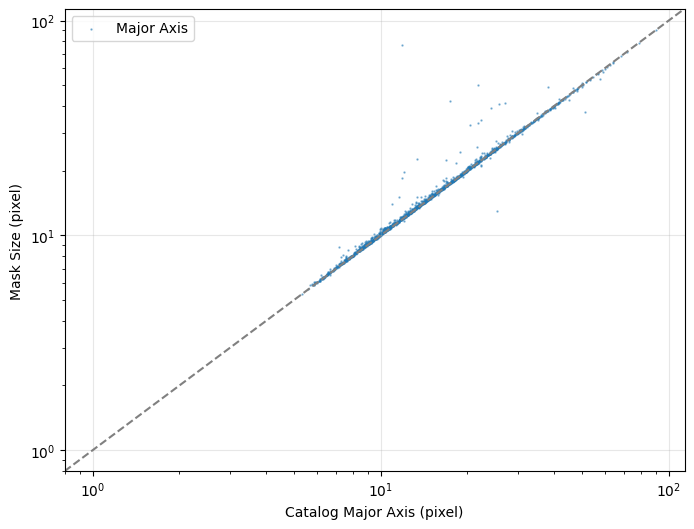

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

cat_maj_px = sub_cat.Maj[~problem_flag].values / 1.5
moment_maj = maj_min_img[0]

kw = dict(s=2, alpha=0.5, marker='.')

ax.scatter(cat_maj_px, moment_maj, label='Major Axis', **kw)
# ax.scatter(cat_maj_px, size, label='Feret Diameter', **kw)

# Fit y = m * x
from sklearn.linear_model import LinearRegression

model = LinearRegression(fit_intercept=False)
model.fit(cat_maj_px.reshape(-1, 1), moment_maj.reshape(-1, 1))
# m = model.coef_[0][0]
# ax.axline([0, 0], slope=m, ls='-', color='red', alpha=0.3, label=f'Fit: y = {m:.2f} x')



ax.axline([0, 0], [1, 1], ls='--', color='gray')
ax.grid(alpha=0.3)
ax.legend()
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('Catalog Major Axis (pixel)')
ax.set_ylabel('Mask Size (pixel)')

fig.show()

Images vs. Catalog Histograms

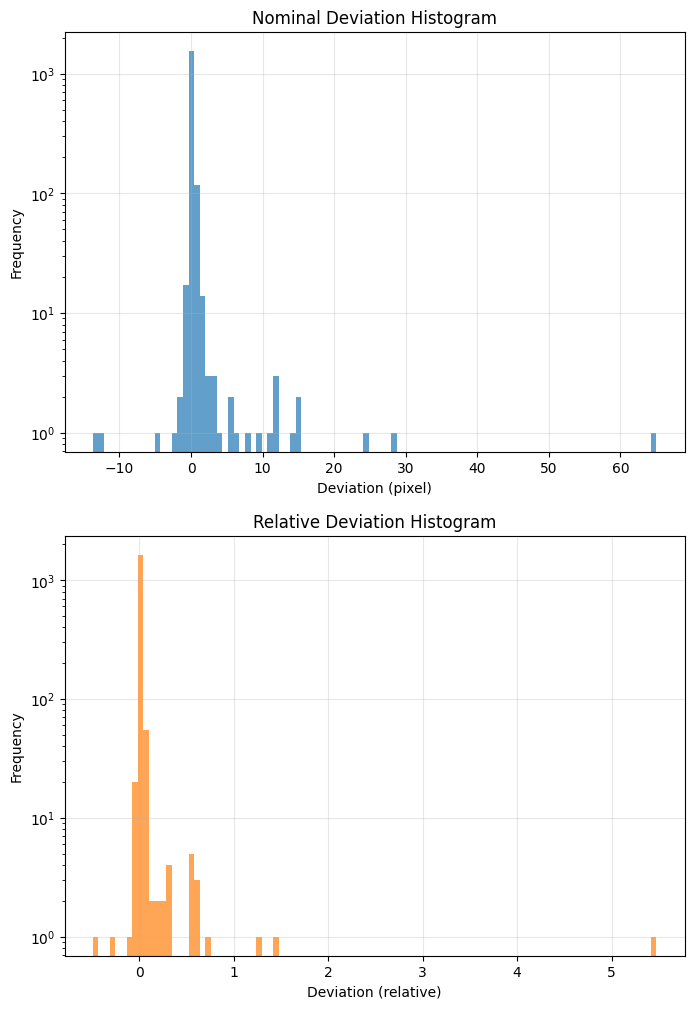

In [21]:
fig, axs = plt.subplots(2, 1, figsize=(8, 12))

hist_kw = dict(bins=100, alpha=0.7, log=True)

# Nominal deviation histogram
axs[0].hist(moment_maj - cat_maj_px, **hist_kw, color='C0')
axs[0].set_title('Nominal Deviation Histogram')
axs[0].set_xlabel('Deviation (pixel)')
axs[0].set_ylabel('Frequency')

# Relative deviation histogram
axs[1].hist((moment_maj - cat_maj_px) / cat_maj_px, **hist_kw, color='C1')
axs[1].set_title('Relative Deviation Histogram')
axs[1].set_xlabel('Deviation (relative)')
axs[1].set_ylabel('Frequency')

for ax in axs:
    ax.grid(alpha=0.3)


Look at outliers (i.e. strong deviation)

In [33]:
cont_coords.shape

(2, 1)

 77%|███████▋  | 20/26 [00:22<00:06,  1.04s/it]/tmp/ipykernel_3306496/3263248880.py:25: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={"projection": wcs})
100%|██████████| 26/26 [00:31<00:00,  1.19s/it]


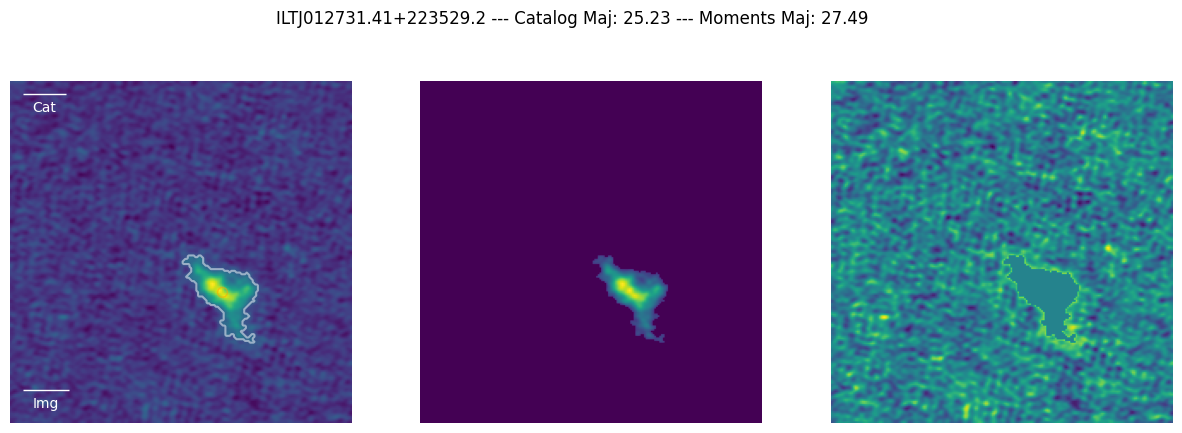

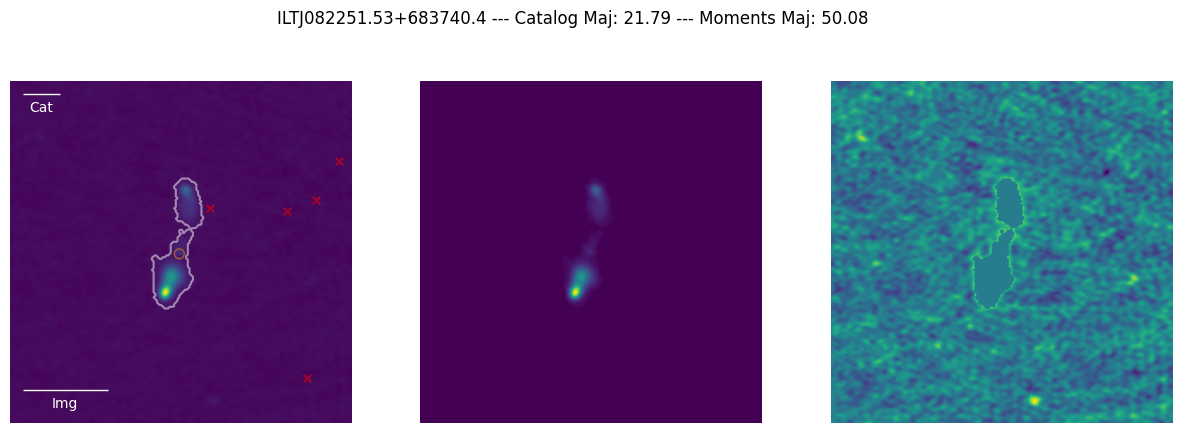

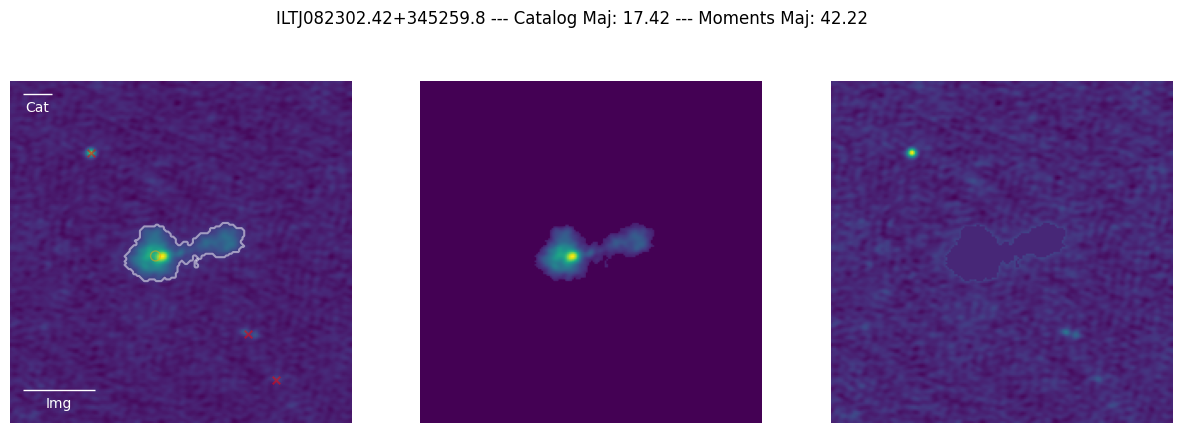

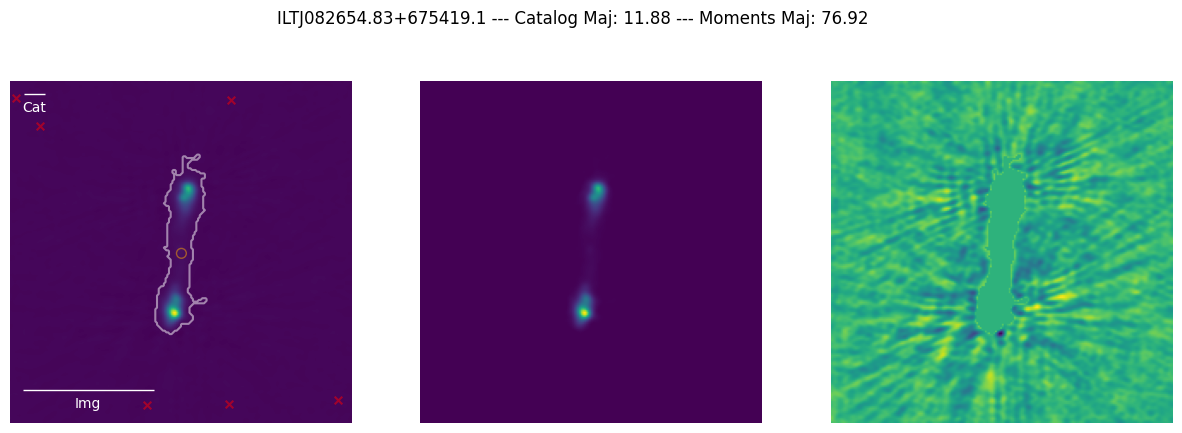

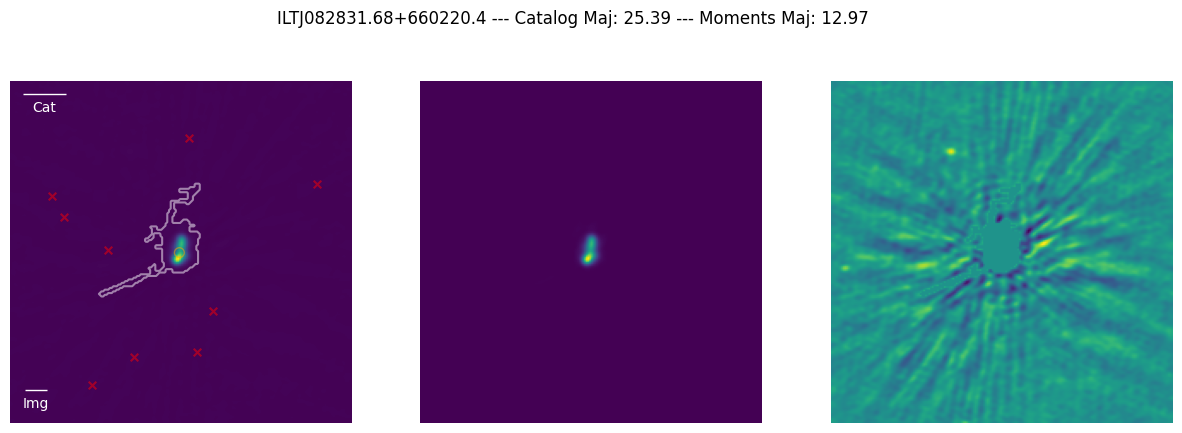

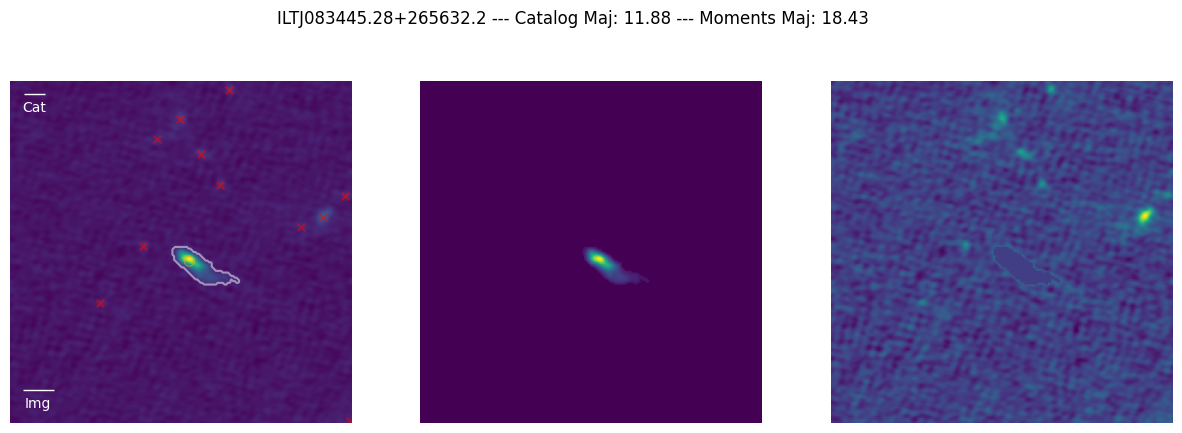

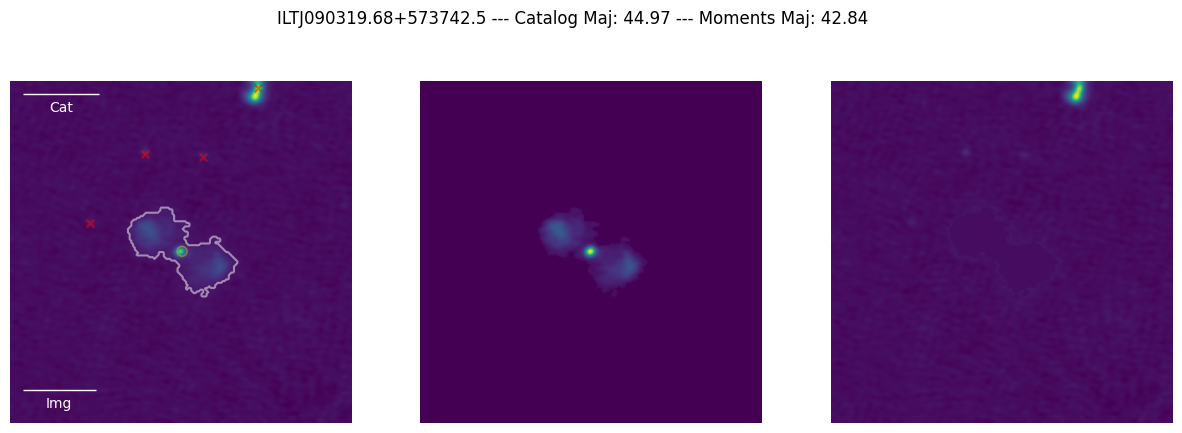

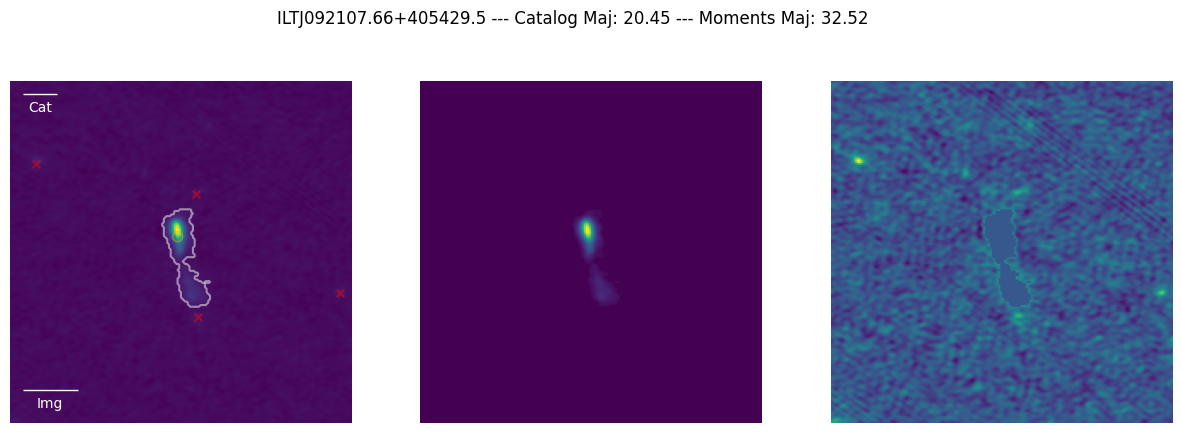

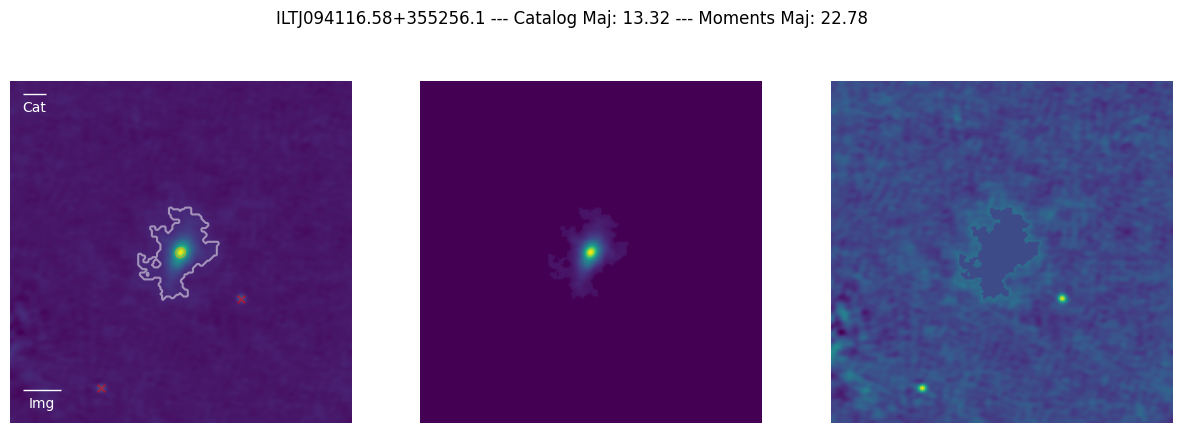

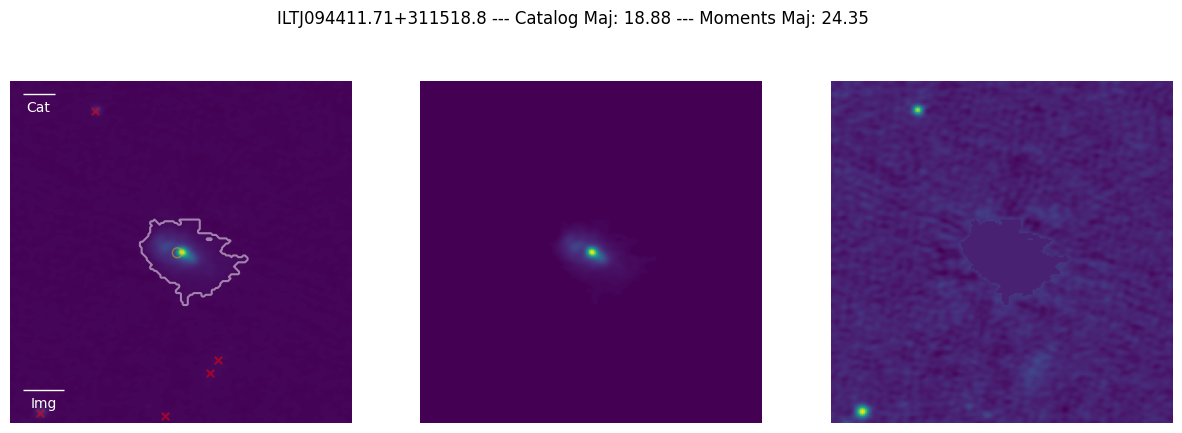

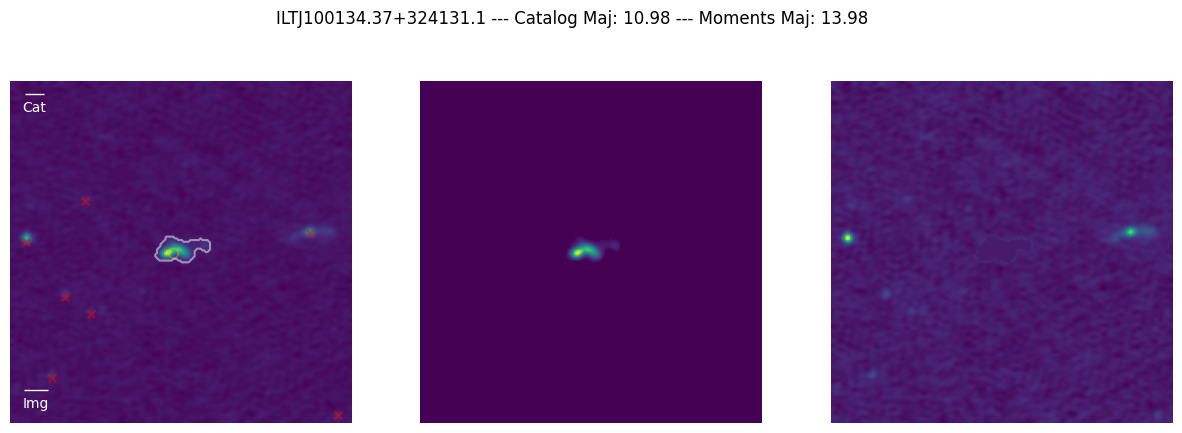

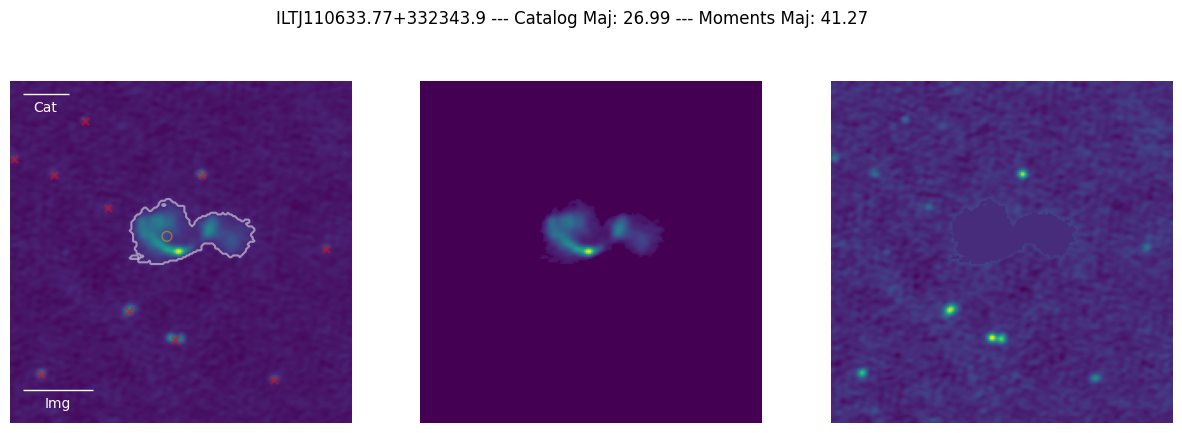

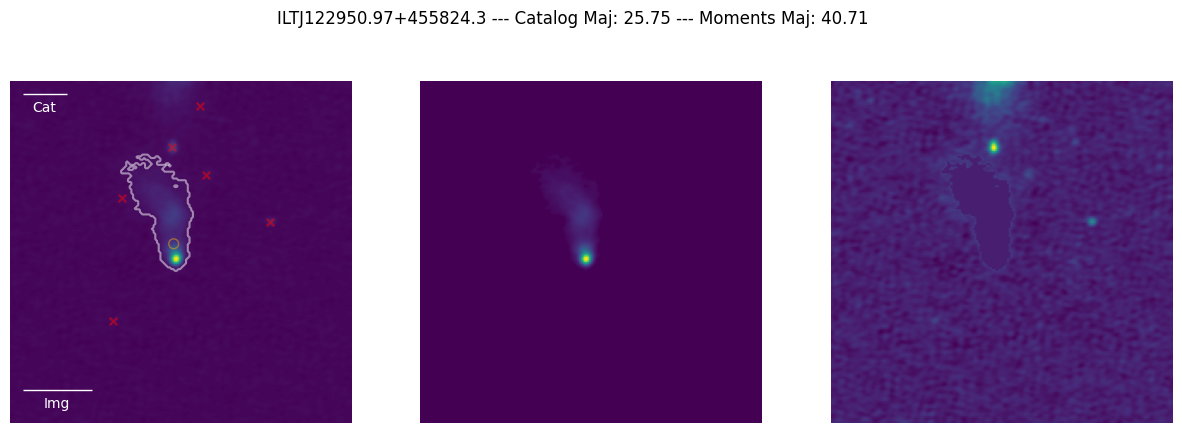

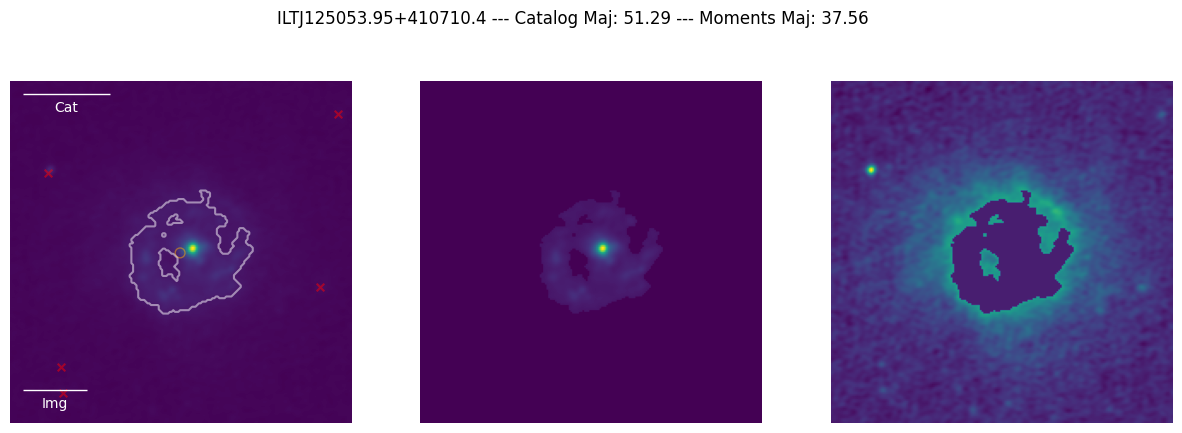

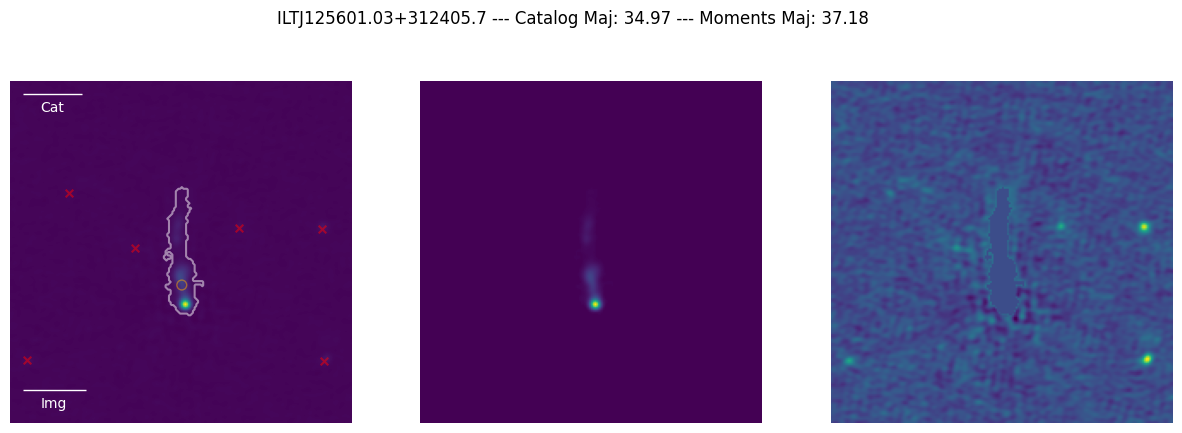

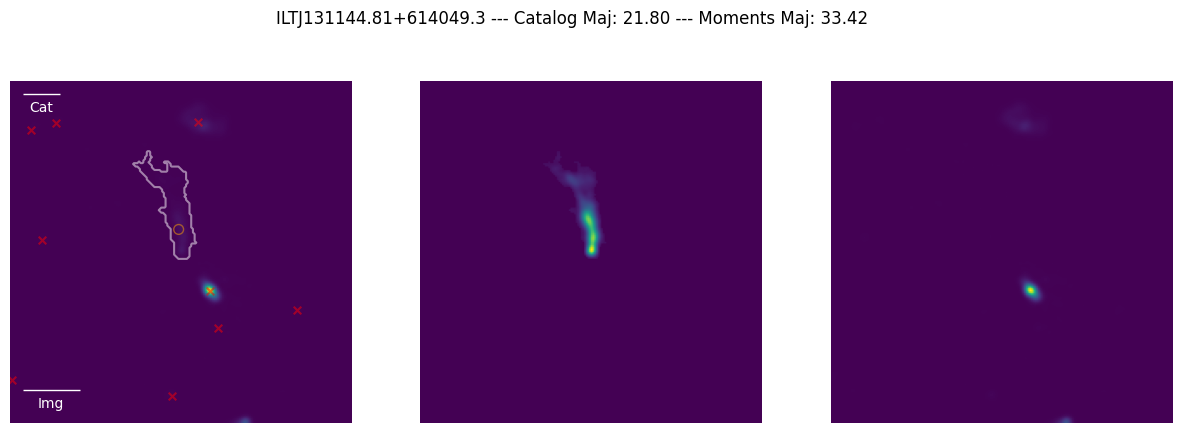

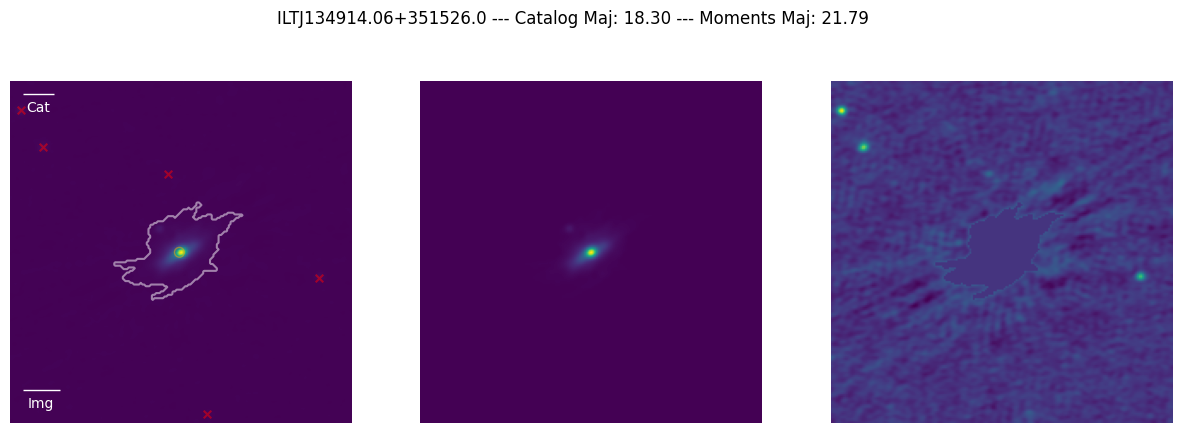

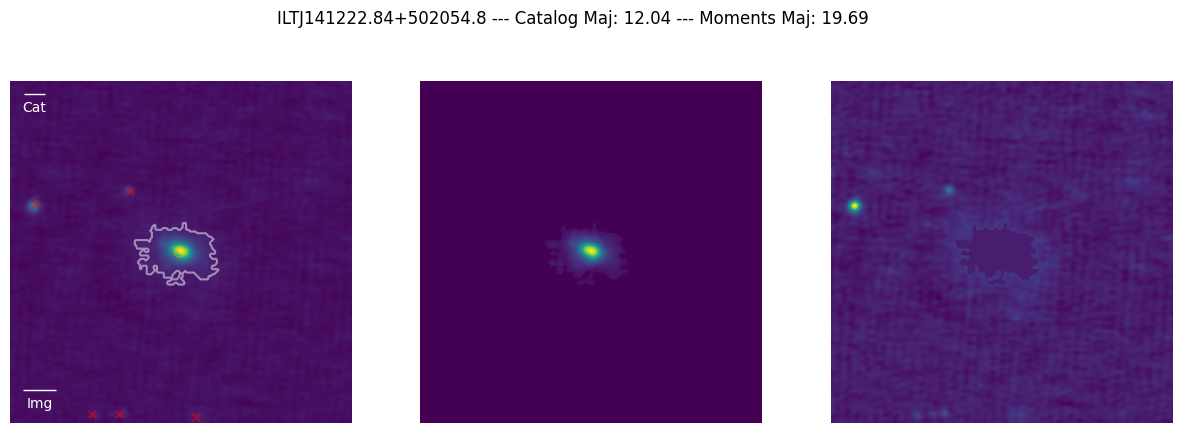

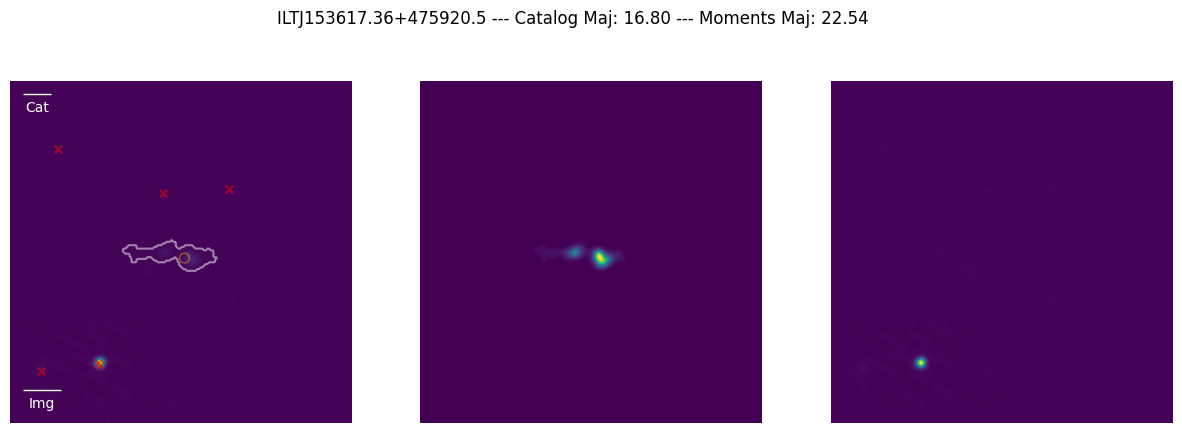

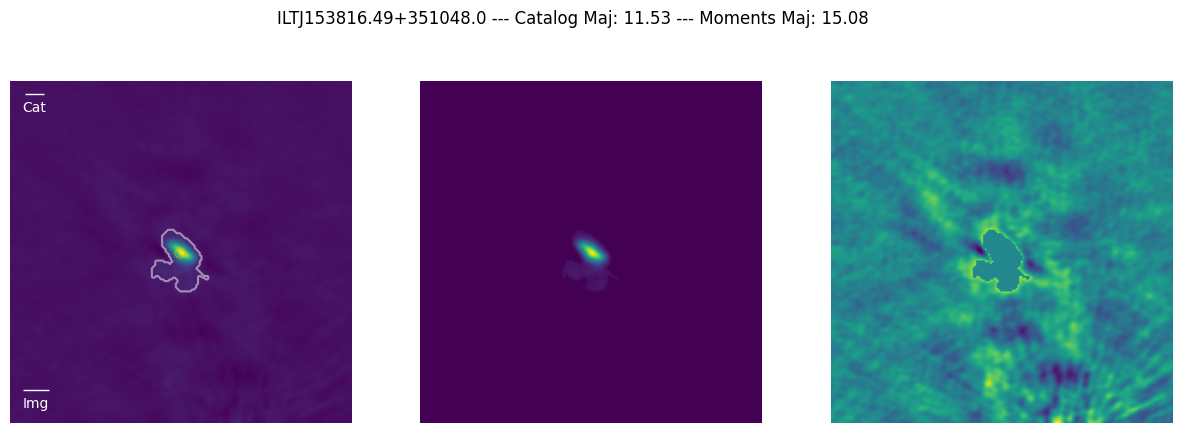

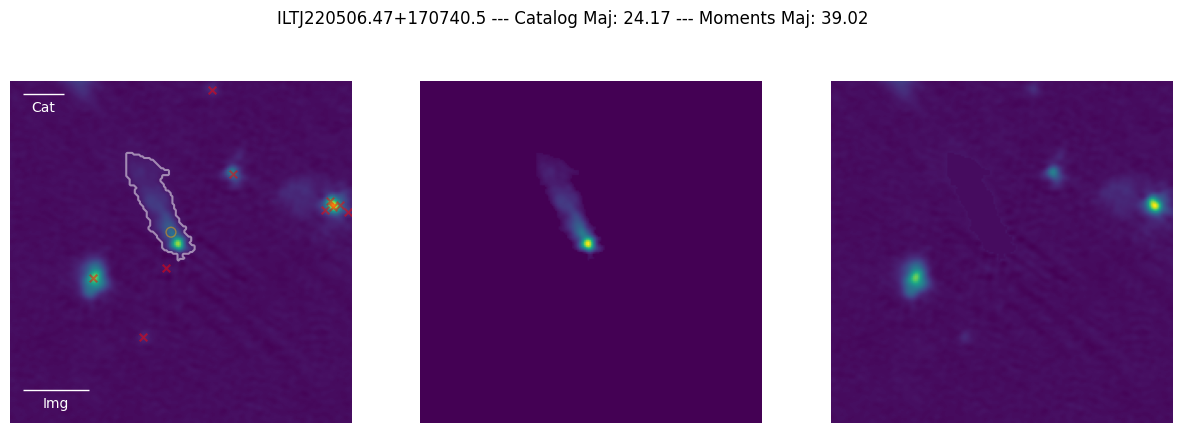

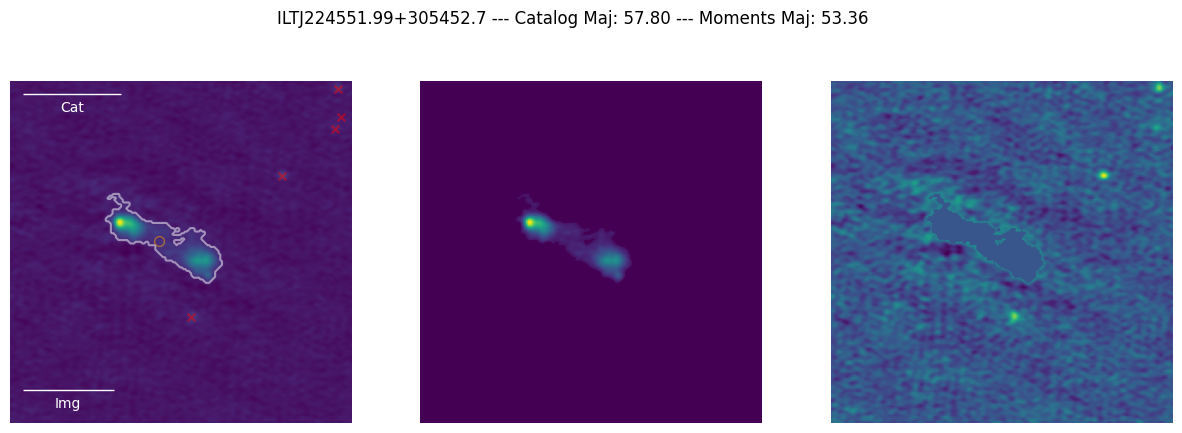

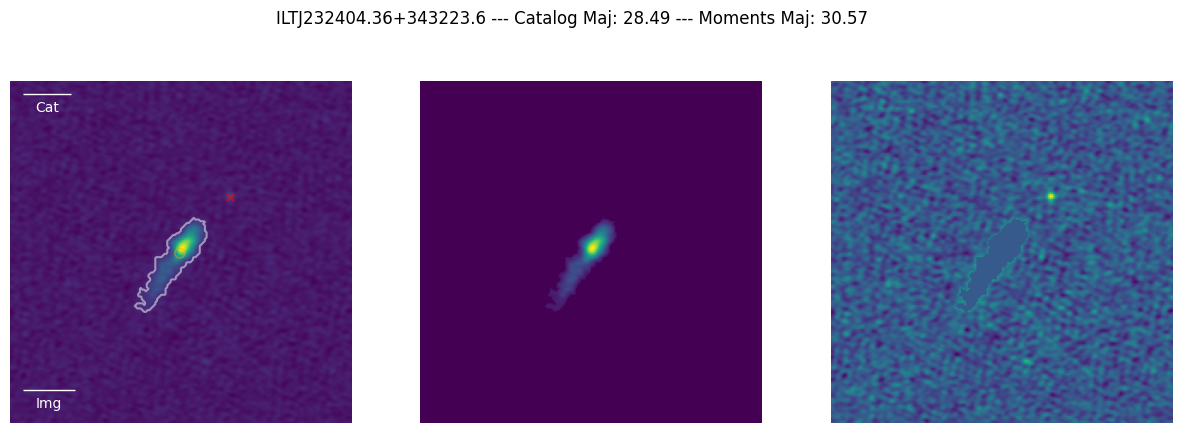

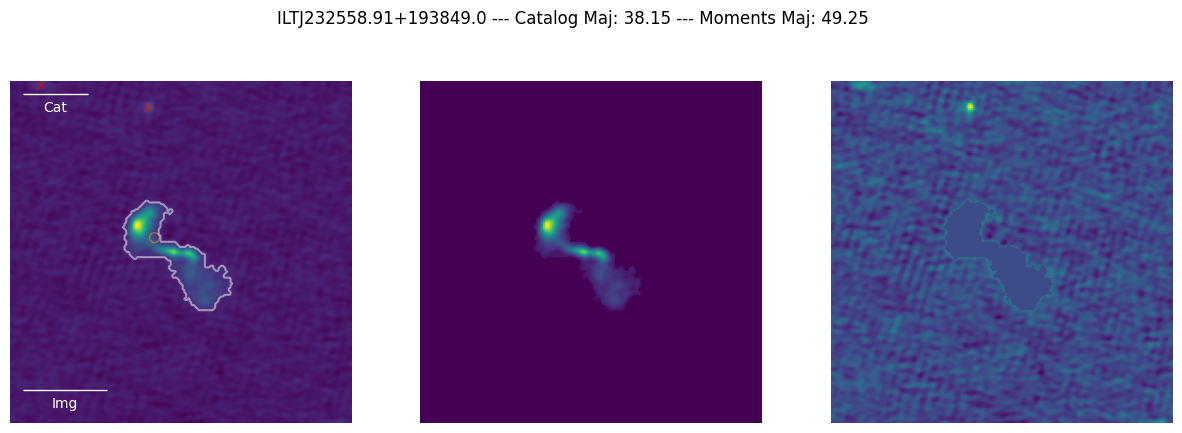

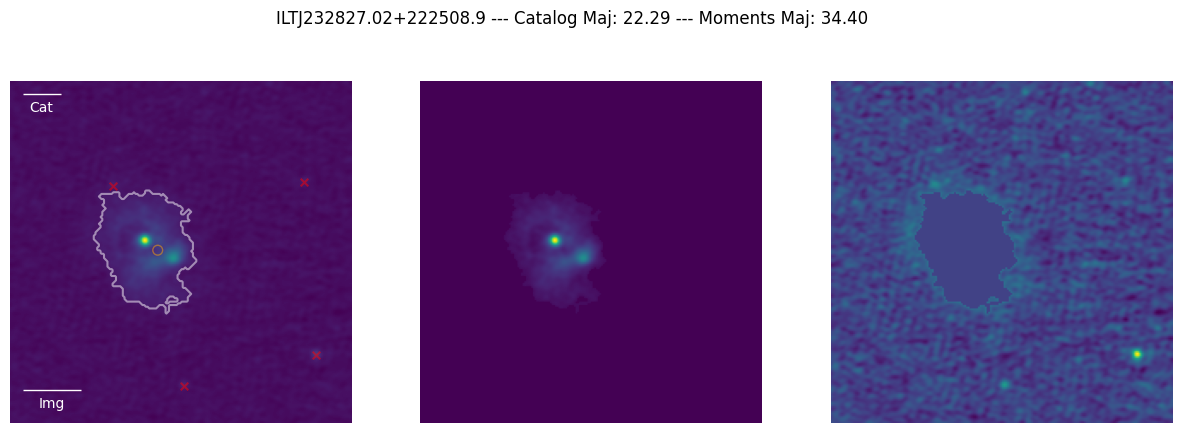

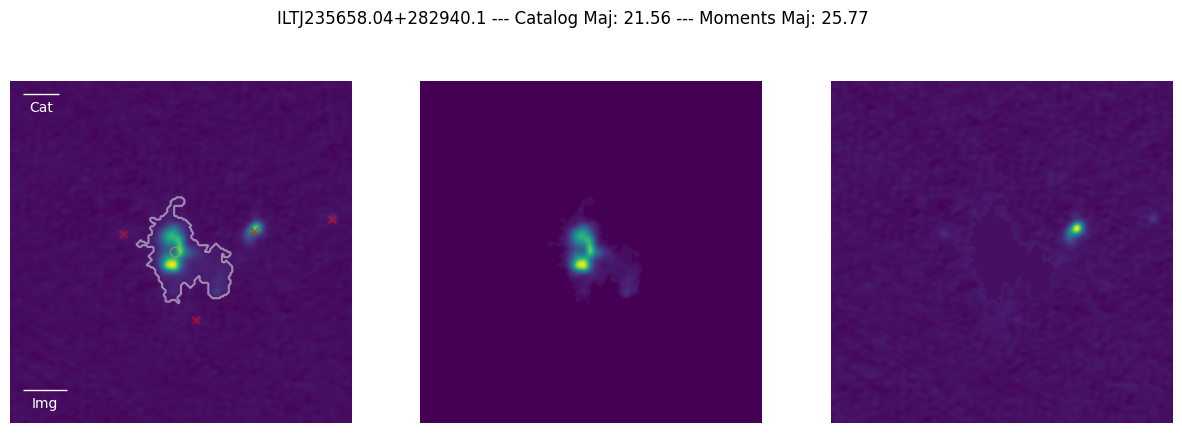

In [35]:
import astropy.units as u
from astropy.visualization.wcsaxes import add_scalebar

# Deviations: nominal and relative
nom_dev = moment_maj - cat_maj_px
rel_dev = (moment_maj - cat_maj_px) / cat_maj_px

# Outlier mask based on threshold
outlier_mask = np.abs(nom_dev) > 2
outlier_mask.sum()

for i in tqdm(range(outlier_mask.sum())):
    img = dset.data[sub_flag][~problem_flag][outlier_mask][i].numpy()
    mask = clean_masks[~problem_flag][outlier_mask][i]
    src = sub_cat[~problem_flag][outlier_mask].iloc[i]

    wcs = make_wcs(img, src)
    components = filter_catalog_by_wcs(cmp_cat, wcs)
    host_coords = components[components.Parent_Source == src.Source_Name][['RA', 'DEC']].values.T
    cont_coords = components[components.Parent_Source != src.Source_Name][['RA', 'DEC']].values.T

    maj_cat = cat_maj_px[outlier_mask][i]
    maj_img = moment_maj[outlier_mask][i]

    fig, axs = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={"projection": wcs})

    axs[0].imshow(img, origin="lower")
    axs[1].imshow(img * mask, origin="lower")
    axs[2].imshow(img * (1 - mask), origin="lower")

    ax = axs[0]
    ax.contour(mask, levels=[0.5], colors="white", alpha=0.5)
    ax.scatter(
        *host_coords,
        transform=ax.get_transform("world"),
        s=50,
        marker="o",
        color="orange",
        facecolor='none',
        alpha=0.5,
    )
    if cont_coords.shape[-1] > 0:
        ax.scatter(
            *cont_coords,
            transform=ax.get_transform("world"),
            s=30,
            color="red",
            marker="x",
            alpha=0.5,
        )

    add_scalebar(
        ax,
        maj_cat * 1.5 * u.arcsec,
        color="white",
        label="Cat",
        corner='top left'
    )
    add_scalebar(
        ax,
        maj_img * 1.5 * u.arcsec,
        color="white",
        label="Img",
        corner='bottom left'
    )
    fig.suptitle(
        src.Source_Name +
        f' --- Catalog Maj: {maj_cat:.2f}'
        f' --- Moments Maj: {maj_img:.2f}'
    )

    for ax in axs:
        ax.axis('off')

    fig.show()

# Investigate good SNR definition

In [9]:
[print(c) for c in cat.columns if 'rms' in c]

Isl_rms


[None]

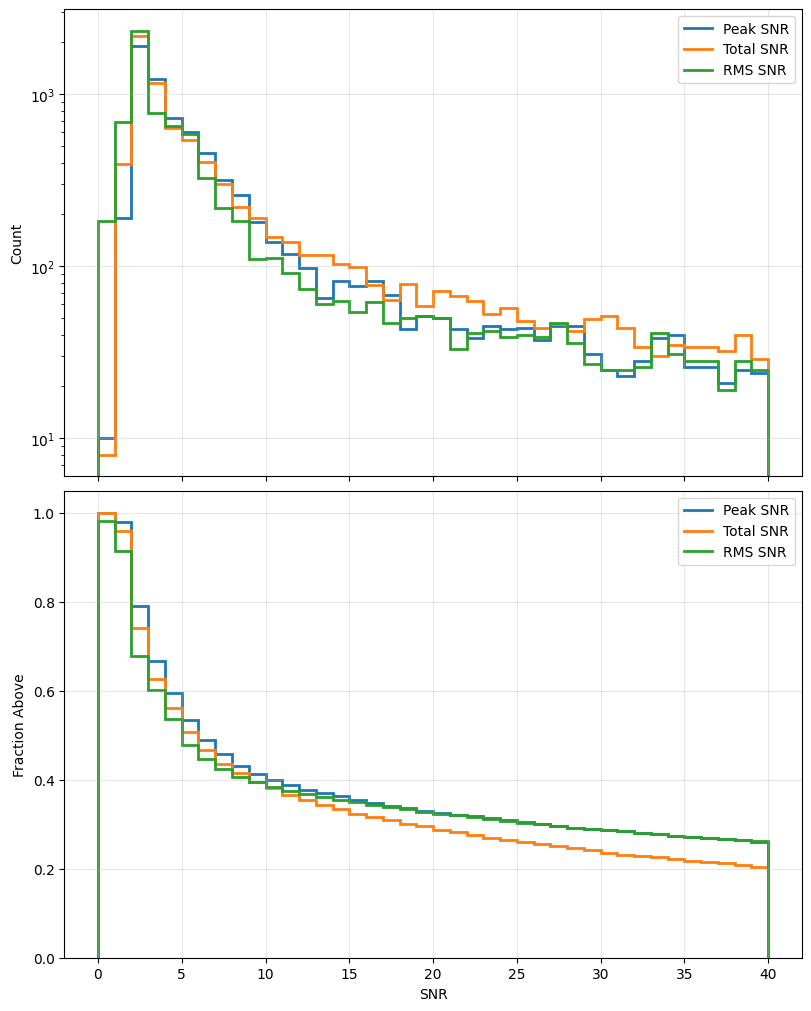

In [16]:
from plotting.image_plots import metric_peek
import matplotlib.pyplot as plt
import numpy as np

cat = dset.catalog

SNR_peak = cat.Peak_flux / cat.E_Peak_flux
SNR_tot = cat.Total_flux / cat.E_Total_flux
SNR_rms = cat.Peak_flux / cat.Isl_rms

fig, axs = plt.subplots(2, 1, figsize=(8, 10), sharex=True, constrained_layout=True)


for SNR, lbl in zip(
    [SNR_peak, SNR_tot, SNR_rms],
    ['Peak SNR', 'Total SNR', 'RMS SNR']
):
    hist_kw = dict(bins=np.linspace(0, 40, 41))
    cts, bins = np.histogram(SNR, **hist_kw)
    contained_above = 1 - cts.cumsum() / len(SNR)

    ax = axs[0]
    ax.stairs(cts, bins, label=lbl, linewidth=2)
    ax.set_ylabel("Count")
    ax.set_yscale('log')

    ax = axs[1]
    ax.set_xlabel("SNR")
    ax.stairs(contained_above, bins, label=lbl, linewidth=2)
    ax.set_ylabel('Fraction Above')


for ax in axs:
    ax.legend()
    ax.grid(alpha=0.3)

fig.show()

In [18]:
dset.data.shape

torch.Size([10000, 200, 200])

Digitizing...


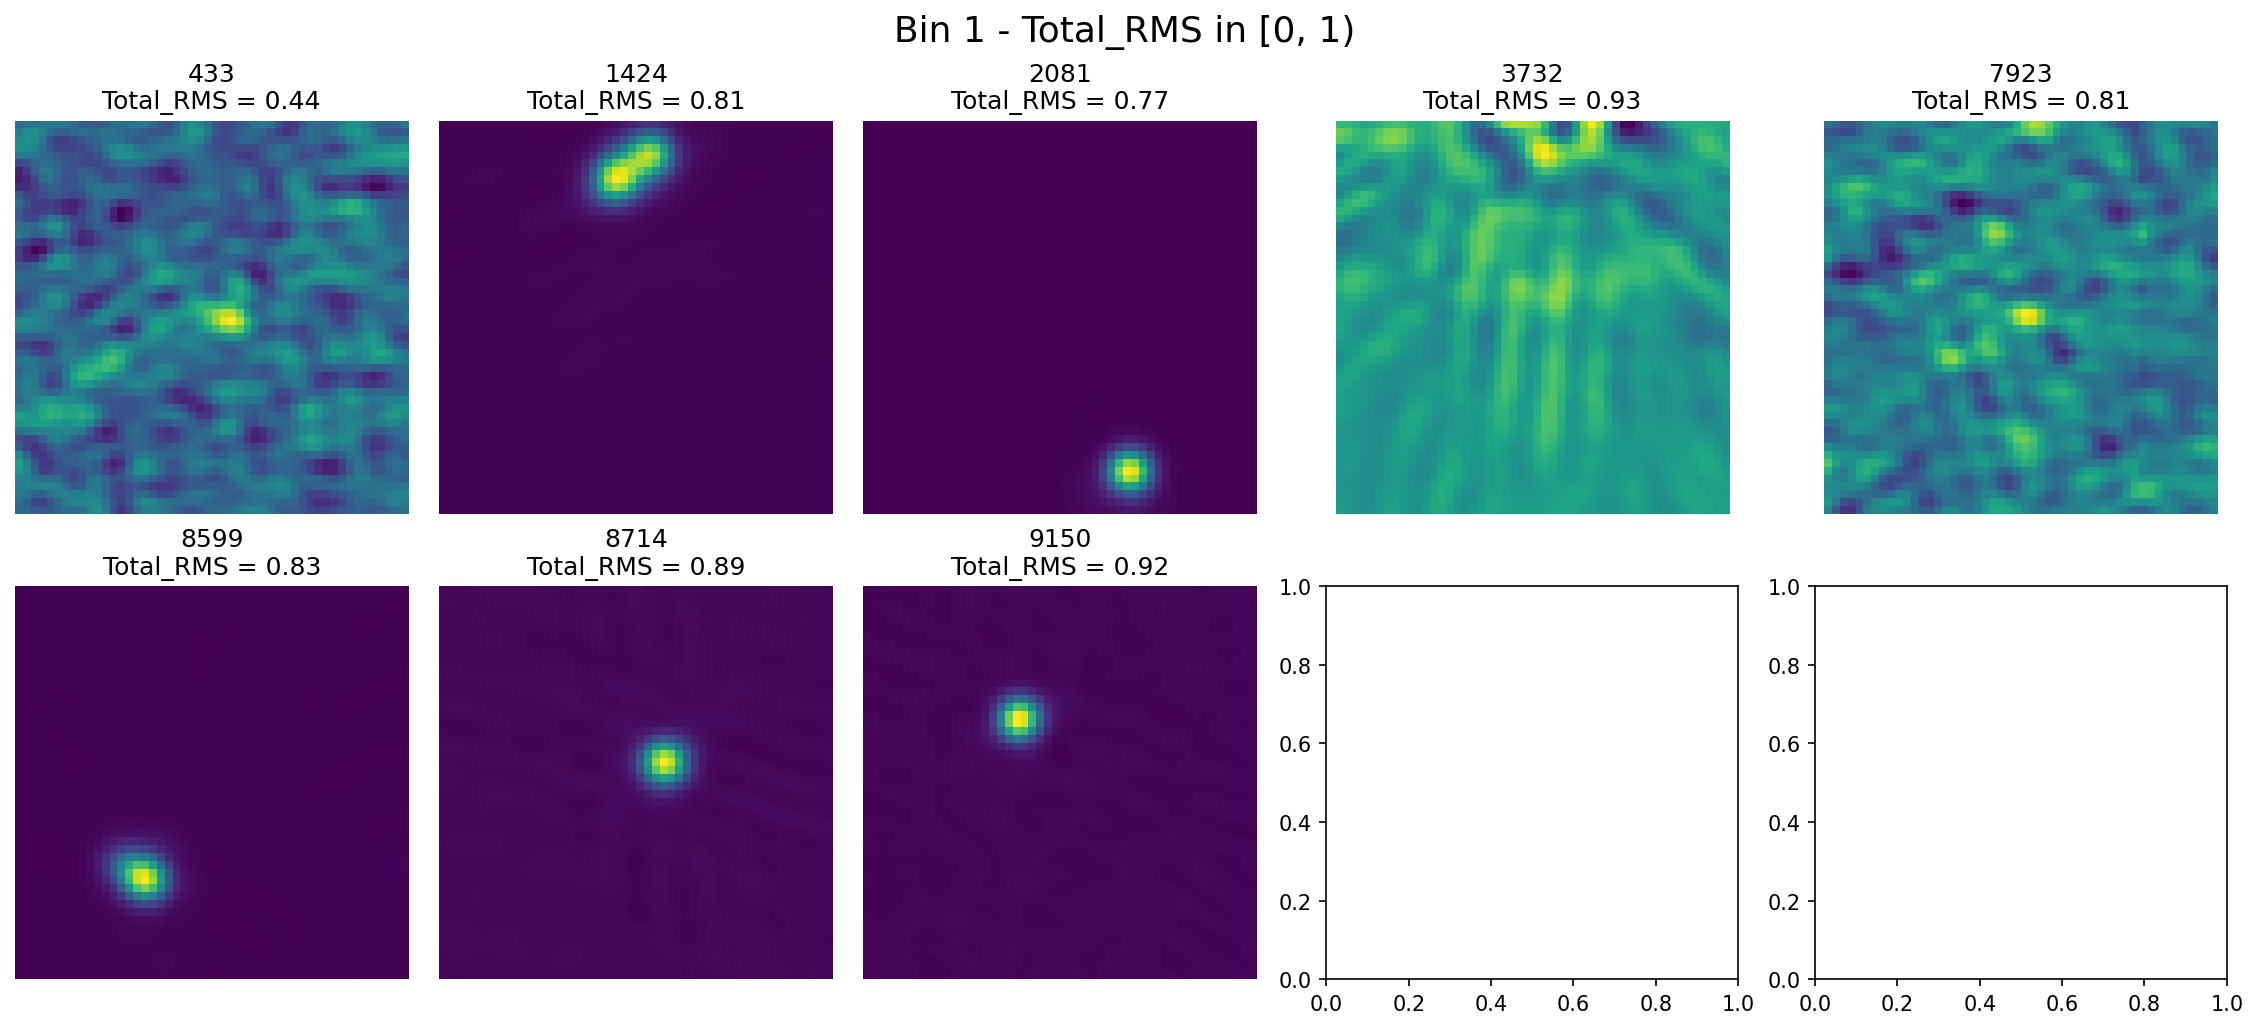

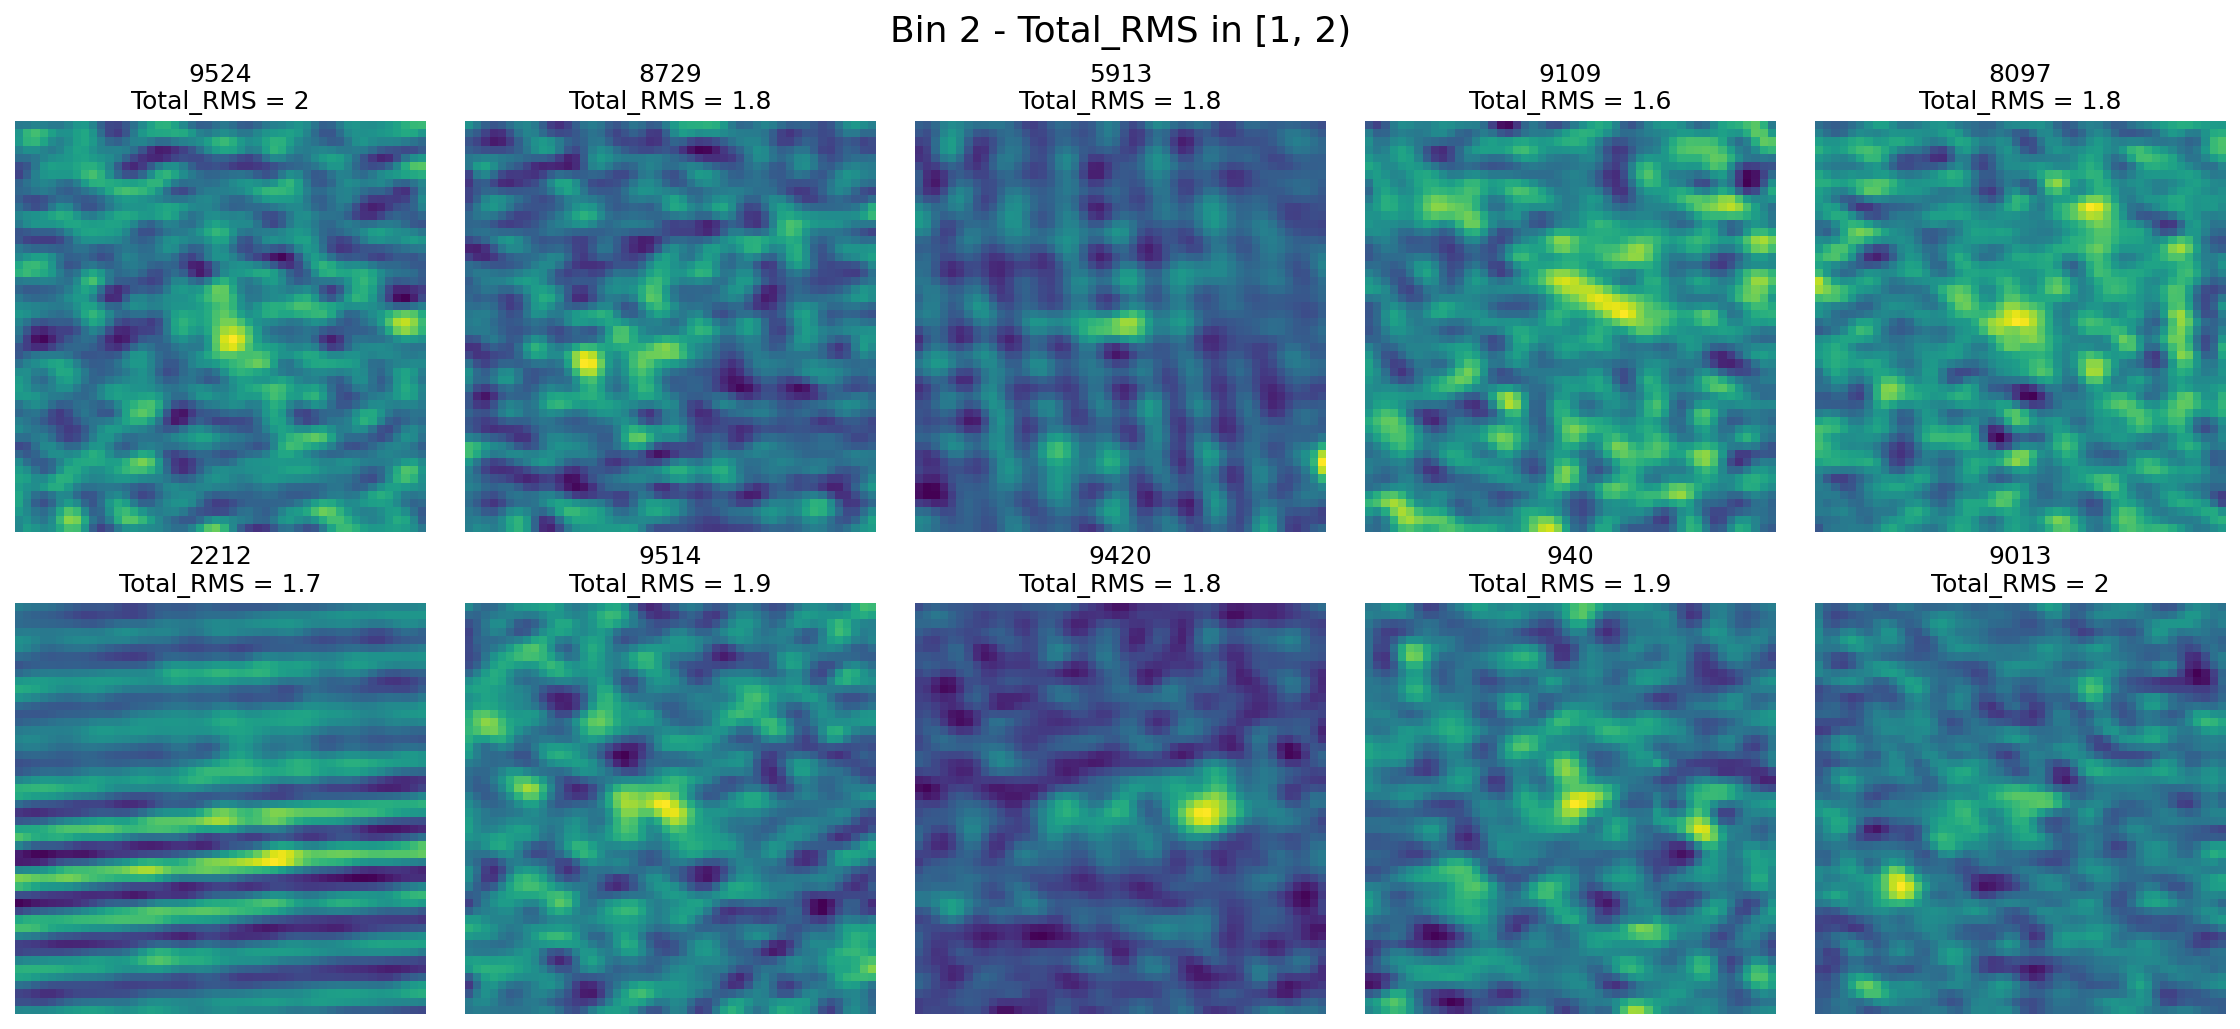

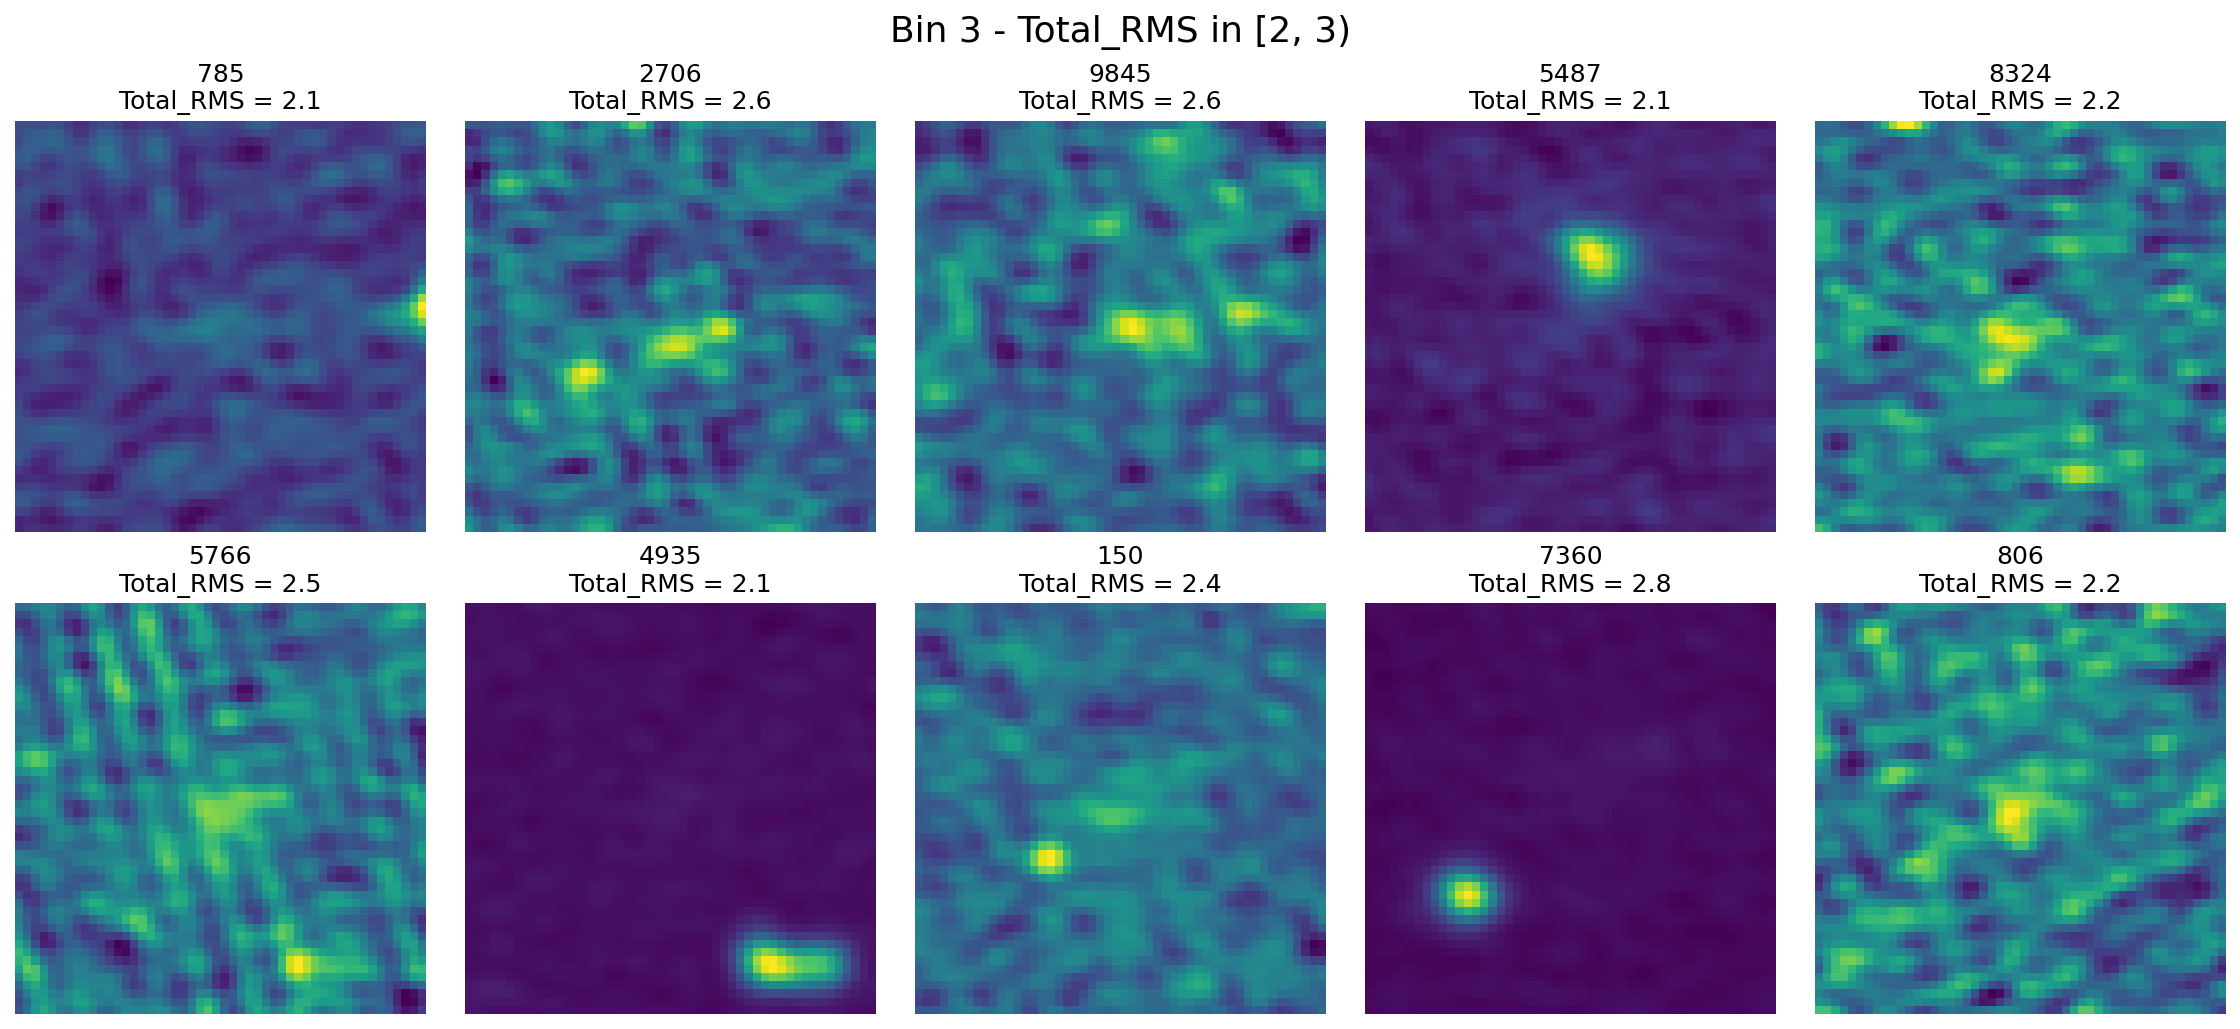

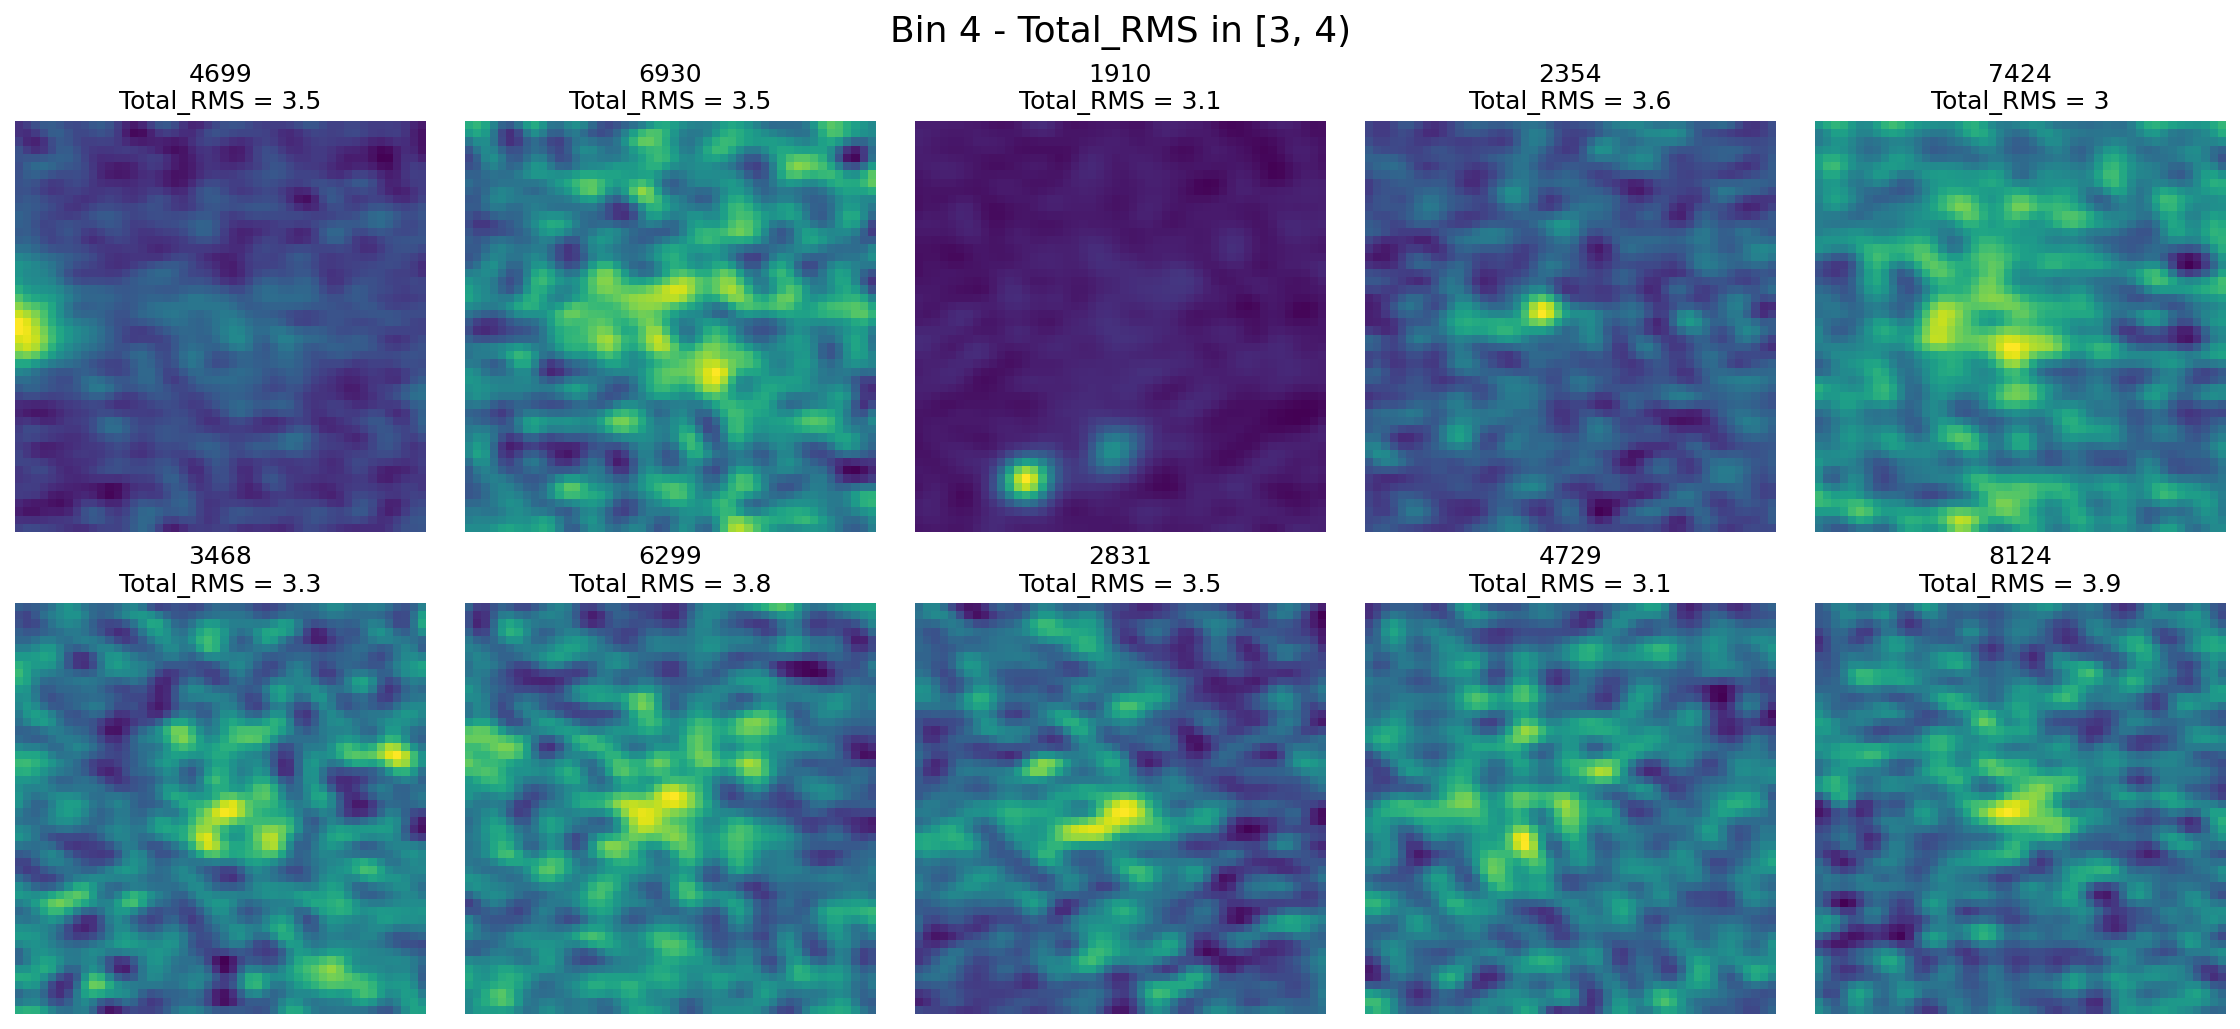

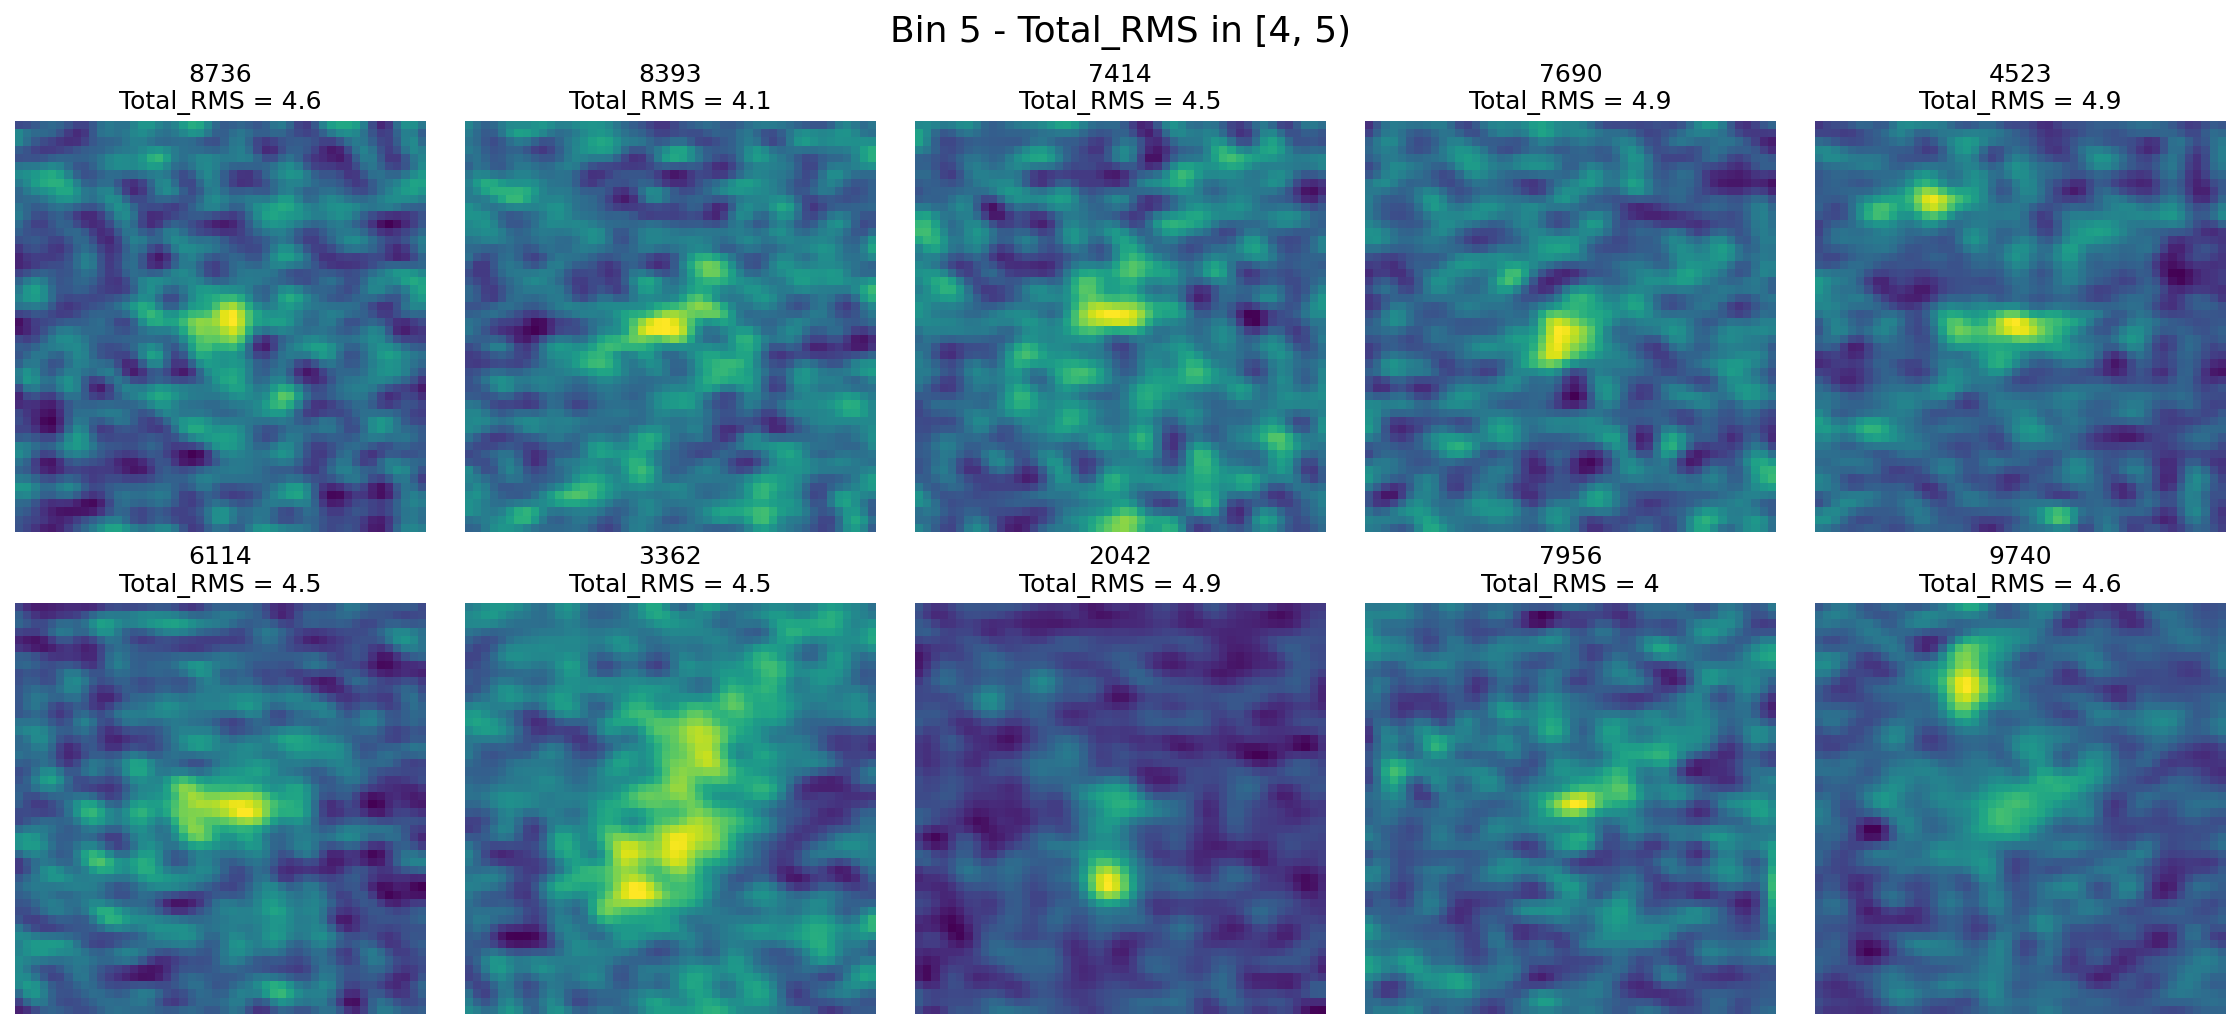

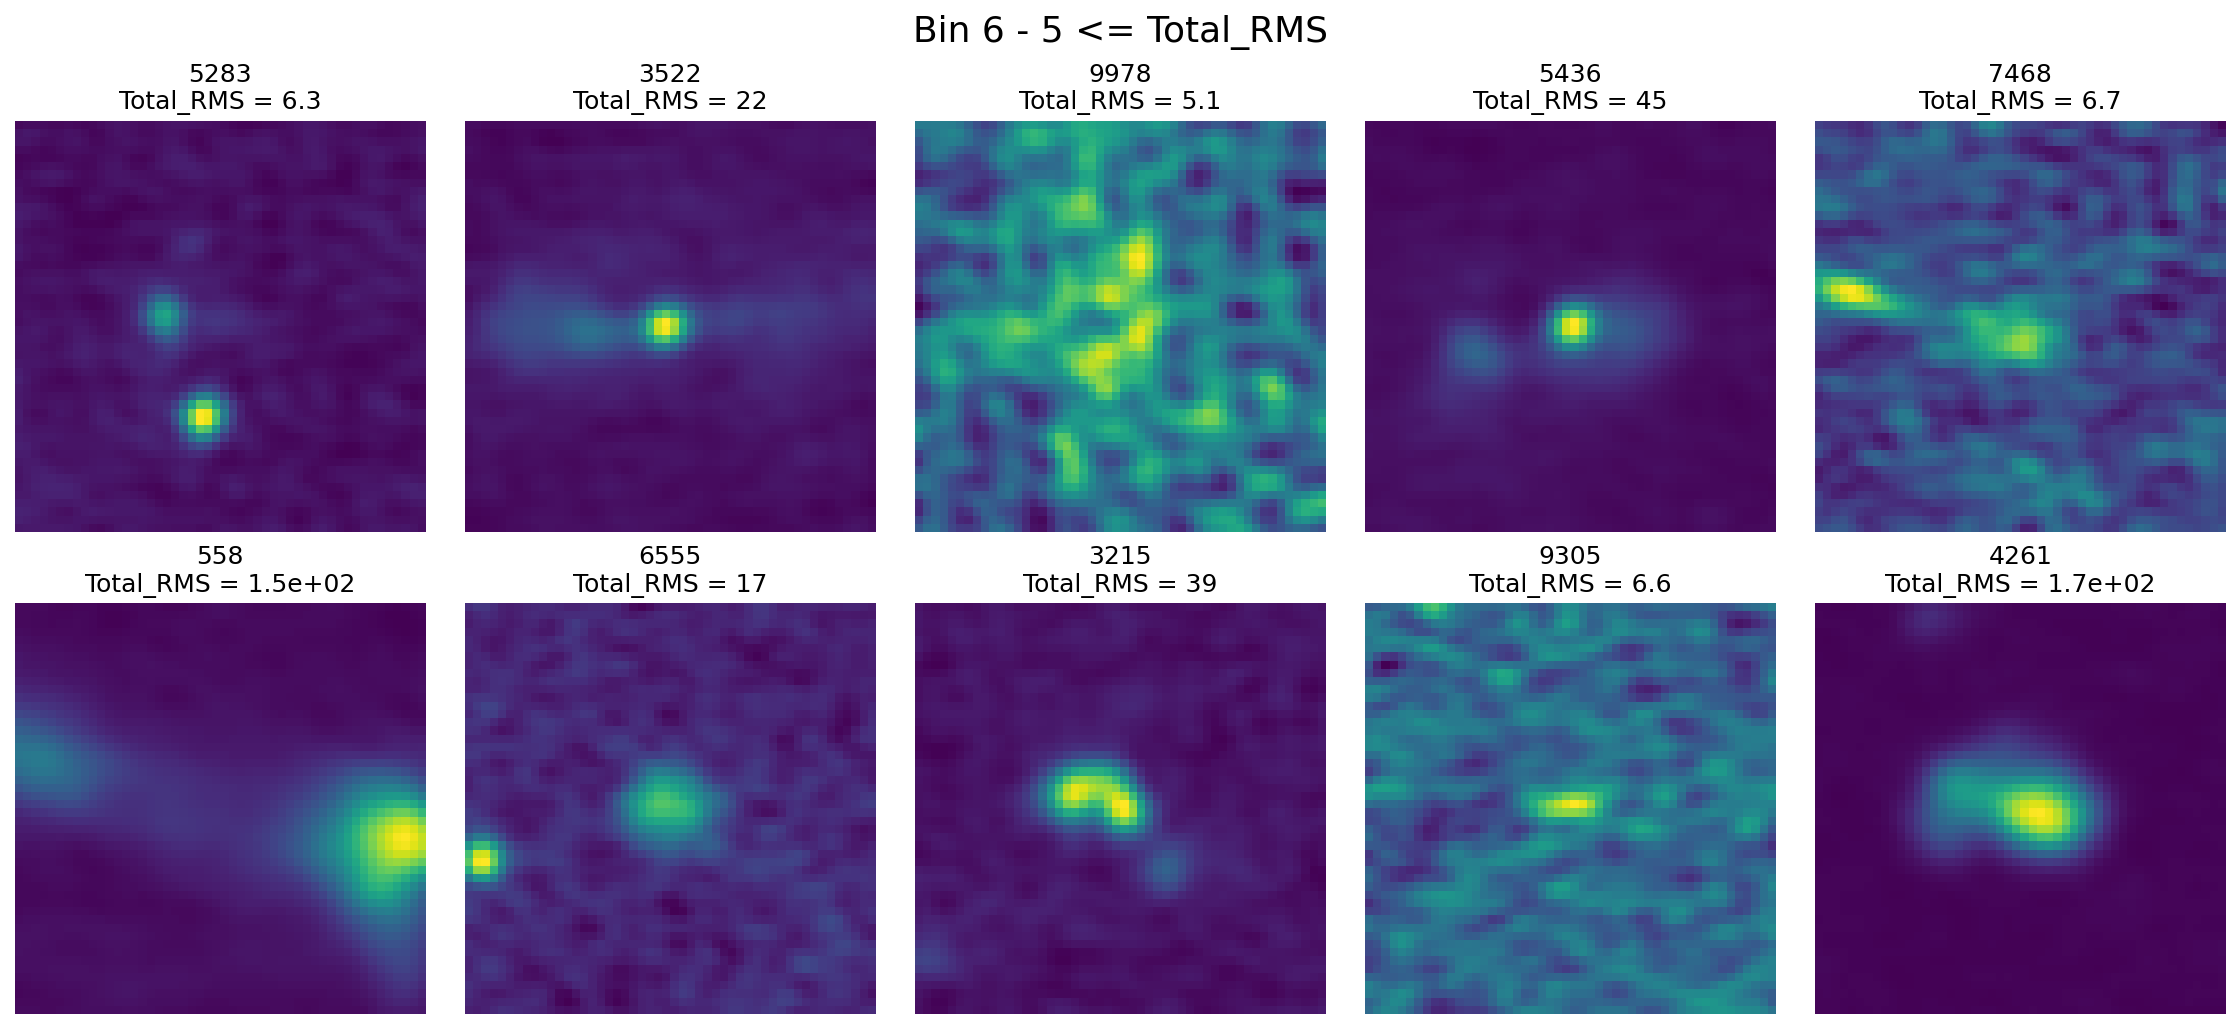

In [20]:
import numpy as np

metric_peek(
    metric=SNR_tot.values,
    edges=np.linspace(0, 5, 6),
    images=dset.data[:, 75:-75, 75:-75],
    metric_name="Total_RMS",
)

In [ ]:
snr_cut = [10, 20, 30]

fig, ax = plt.subplots(1, 1, figsize=(12, 6))


for snr in snr_cut:
    LAS = cat.LAS[SNR_tot >= snr]
    cts, bins = np.histogram(LAS, bins=np.linspace(0, 750, 100))
    cts_above = len(LAS) - cts.cumsum()
    ax.stairs(cts_above, bins, label=f"SNR >= {snr}", linewidth=2)

ax.axvline(120, color="C2", linestyle="--", label="LAS = 120 arcmin")

ax.set_xlabel("LAS (arcmin)")
ax.set_ylabel("Counts above LAS")
ax.legend()
ax.set_yscale("log")
ax.grid(alpha=0.3)

fig.show()

# Restore model image from components

In [ ]:
# Make images of components
def make_component_images(src_cmp, wcs, img_shape):
    from astropy.coordinates import SkyCoord
    from astropy.wcs.utils import skycoord_to_pixel

    component_images = []

    for _, row in src_cmp.iterrows():

        # Create a blank image
        component_img = np.zeros(img_shape, dtype=np.float32)

        # Make a centered 2d gaussian
        majax, minax, angle = row.Maj, row.Min, row.PA  # arcsec, arcsec, degrees
        y, x = np.ogrid[: img_shape[0], : img_shape[1]]

        # Gaussian parameters
        arcsec2pix = lambda x: x / (wcs.wcs.cdelt[1] * 3600)
        sigma_x = arcsec2pix(majax) / 2.355
        sigma_y = arcsec2pix(minax) / 2.355

        # Create the Gaussian, centered
        gaussian = row.Peak_flux * np.exp(
            -(
                (x - img_shape[0] // 2) ** 2 / (2 * sigma_x**2)
                + (y - img_shape[1] // 2) ** 2 / (2 * sigma_y**2)
            )
        )
        # Rotate the Gaussian
        from scipy.ndimage import rotate

        gaussian = rotate(gaussian, angle, reshape=False)

        # Place the Gaussian at the pixel location
        pixel_coord = wcs.world_to_array_index(SkyCoord(row.RA, row.DEC, unit="deg"))
        y0, x0 = pixel_coord
        y0, x0 = int(y0), int(x0)
        y_start = max(0, y0 - img_shape[0] // 2)
        y_end = min(img_shape[0], y0 + img_shape[0] // 2)
        x_start = max(0, x0 - img_shape[1] // 2)
        x_end = min(img_shape[1], x0 + img_shape[1] // 2)

        # Place the Gaussian in the component image
        component_img[y_start:y_end, x_start:x_end] = gaussian[
            img_shape[1] - y_end : img_shape[1] - y_start,
            img_shape[0] - x_end : img_shape[0] - x_start,
        ]

        # Add to the list of component images
        component_images.append(component_img)

    return component_images

In [ ]:
from astropy.wcs import WCS
import matplotlib.pyplot as plt

import numpy as np

random_index = np.random.randint(0, len(sub_cat), 1)
print(random_index)
cmp_cat[cmp_cat.Parent_Source == sub_cat.iloc[random_index].Source_Name.values[0]]

# Get image array and source information
img = dset.data[sub_flag][random_index].squeeze()
src = sub_cat.iloc[random_index]

# Make wcs object
center_coord = src.RA.values[0], src.DEC.values[0]
if src.optRA.values[0] is not None:
    center_coord = src.optRA.values[0], src.optDec.values[0]

wcs = WCS(naxis=2)
wcs.wcs.crpix = [img.shape[1] // 2, img.shape[0] // 2]
wcs.wcs.cdelt = [-1.5 / 3600, 1.5 / 3600]  # degrees per pixel (1.5 arcsec)
wcs.wcs.crval = center_coord
wcs.wcs.ctype = ["RA---SIN", "DEC--SIN"]

# Get source components
src_cmp = cmp_cat[cmp_cat.Parent_Source == src.Source_Name.values[0]]
src_cmp.RA.values

# Make component images and model image
components = make_component_images(src_cmp, wcs, img.shape)
model_img = np.sum(components, axis=0)

# Plot everything with WCS
from astropy.visualization import simple_norm
from astropy.visualization.wcsaxes import WCSAxes

fig, axs = plt.subplots(1, 2, subplot_kw={"projection": wcs}, figsize=(10, 5))


axs[0].imshow(img, origin="lower", cmap="gray")
axs[1].imshow(model_img, origin="lower", cmap="gray")

for ax in axs:
    ax.scatter(
        src.RA.values[0],
        src.DEC.values[0],
        color="red",
        marker="x",
        s=10,
        label="Source",
        transform=ax.get_transform("world"),
    )
    ax.scatter(
        src_cmp.RA.values,
        src_cmp.DEC.values,
        color="blue",
        marker="x",
        s=10,
        label="Components",
        transform=ax.get_transform("world"),
    )